# Credit Scoring — Give Me Some Credit & Home Credit

---
## Cấu trúc notebook

| Phần | Nội dung | Dùng chung? |
|------|----------|-------------|
| 0 | Setup & cài thư viện | Chung |
| 1 | Shared utilities (evaluate, plot, TabNet classes) | Chung |
| A | Give Me Some Credit — Load → EDA → FE → Preprocess → Train | Riêng |
| B | Home Credit — Load → Aggregate → EDA → FE → Preprocess → Train | Riêng |
| C | So sánh kết quả giữa 2 dataset | Chung |
| D | Lưu model để demo | Dùng theo GMSC |

# 0. Setup & Reproducibility

In [1]:
import os, sys, time, warnings, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
SAVE_DIR   = f'{OUTPUT_DIR}/saved_models'


print("python  :", sys.version)
print("platform:", platform.platform())
print("numpy   :", np.__version__)
print("pandas  :", pd.__version__)


python  : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
platform: Linux-6.12.90+-x86_64-with-glibc2.35
numpy   : 2.4.6
pandas  : 2.3.3


In [2]:
import torch
import optuna
import shap
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.metrics import (
    roc_auc_score, roc_curve, average_precision_score,
    precision_recall_curve, confusion_matrix, classification_report,
)
from category_encoders import WOEEncoder
from catboost import CatBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import LabelEncoder, QuantileTransformer

optuna.logging.set_verbosity(optuna.logging.WARNING)
print('Imports OK')


Imports OK


In [3]:
!pip install pytorch_tabnet 
from pytorch_tabnet.tab_model import TabNetClassifier
print('pytorch_tabnet OK')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 103.7 MB/s eta 0:00:0000:01:01
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.

---
# 1. Shared Utilities
> Tất cả hàm dùng chung cho cả 2 dataset.  
> Chạy một lần, dùng xuyên suốt notebook.


## 1.1 Evaluate metrics

In [4]:
def evaluate(model, X, y_true, label='', threshold=None):
    y_prob = model.predict_proba(X)[:, 1]
    y_true = np.array(y_true)
    auc    = roc_auc_score(y_true, y_prob)
    ap     = average_precision_score(y_true, y_prob)
    gini   = 2 * auc - 1
    fpr, tpr, thr_roc = roc_curve(y_true, y_prob)
    ks_scores   = tpr - fpr
    ks          = ks_scores.max()
    
    if threshold is not None:
        best_thresh = threshold
    else:
        best_thresh = float(thr_roc[ks_scores.argmax()])
    
    y_pred      = (y_prob >= best_thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    recall_bad     = tp / (tp + fn + 1e-8)
    recall_good    = tn / (tn + fp + 1e-8)
    precision_bad  = tp / (tp + fp + 1e-8)
    f1_bad         = 2 * precision_bad * recall_bad / (precision_bad + recall_bad + 1e-8)
    if label:
        print(f"  [{label}] AUC={auc:.4f}  Gini={gini:.4f}  KS={ks:.4f}  F1(bad)={f1_bad:.4f}")
    return dict(auc=auc, gini=gini, ks=ks, ap=ap, threshold=best_thresh,
                recall_bad=recall_bad, recall_good=recall_good,
                precision_bad=precision_bad, f1_bad=f1_bad,
                tp=int(tp), fp=int(fp), tn=int(tn), fn=int(fn))

## 1.2 Summarize & 1.3 Plot baseline results

In [5]:
def summarize_results(results):
    rows = []
    for name, r in results.items():
        tr, te = r['train'], r['test']
        rows.append({
            'Model'          : name,
            'Train AUC'      : round(tr['auc'],           4),
            'Test AUC'       : round(te['auc'],           4),
            'Test Gini'      : round(te['gini'],          4),
            'Test KS'        : round(te['ks'],            4),
            'Precision (Bad)': round(te['precision_bad'], 4),
            'Recall (Bad)'   : round(te['recall_bad'],    4),
            'Recall (Good)'  : round(te['recall_good'],   4),
            'F1 (Bad)'       : round(te['f1_bad'],        4),
            'TP': int(te['tp']), 'FP': int(te['fp']),
            'TN': int(te['tn']), 'FN': int(te['fn']),
            'Threshold'      : round(te['threshold'],     4),
            'Train Time (s)' : r['train_time_s'],
        })
    return (pd.DataFrame(rows)
              .sort_values('Test AUC', ascending=False)
              .reset_index(drop=True))

def append_to_summary(df_summary, model_name, train_m, test_m, train_time=None):
    new_row = pd.DataFrame([{
        'Model'          : model_name,
        'Train AUC'      : round(train_m['auc'],           4),
        'Test AUC'       : round(test_m['auc'],            4),
        'Test Gini'      : round(test_m['gini'],           4),
        'Test KS'        : round(test_m['ks'],             4),
        'Precision (Bad)': round(test_m['precision_bad'],  4),
        'Recall (Bad)'   : round(test_m['recall_bad'],     4),
        'Recall (Good)'  : round(test_m['recall_good'],    4),
        'F1 (Bad)'       : round(test_m['f1_bad'],         4),
        'TP': int(test_m['tp']), 'FP': int(test_m['fp']),
        'TN': int(test_m['tn']), 'FN': int(test_m['fn']),
        'Threshold'      : round(test_m['threshold'],      4),
        'Train Time (s)' : train_time,
    }])
    df_summary = df_summary[df_summary['Model'] != model_name].reset_index(drop=True)
    return (pd.concat([df_summary, new_row], ignore_index=True)
              .sort_values('Test AUC', ascending=False)
              .reset_index(drop=True))


def plot_baseline(df_summary, title_suffix='', output_dir=OUTPUT_DIR):
    tag   = title_suffix.replace(' ', '_').lower()
    names = df_summary['Model']
    x     = np.arange(len(names))
    w     = 0.18

    fig, ax = plt.subplots(figsize=(14, 6))
    for i, (m, c) in enumerate(zip(
        ['Test AUC','Test Gini','Test KS','F1 (Bad)','Recall (Bad)'],
        ['#2E86C1','#1ABC9C','#E67E22','#8E44AD','#E74C3C']
    )):
        ax.bar(x + i*w, df_summary[m], w, label=m, color=c, alpha=0.85)
    ax.set_xticks(x + w*2)
    ax.set_xticklabels(names, rotation=25, ha='right', fontsize=9)
    ax.set_title(f'Baseline Comparison {title_suffix}', fontsize=13)
    ax.legend(loc='lower right', fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/baseline_metrics_{tag}.png', dpi=150)
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x-w/2, df_summary['Train AUC'], w, label='Train AUC', color='#2E86C1', alpha=0.85)
    ax.bar(x+w/2, df_summary['Test AUC'],  w, label='Test AUC',  color='#E74C3C', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=25, ha='right', fontsize=9)
    ax.set_title(f'Train vs Test AUC — Overfit Check {title_suffix}', fontsize=13)
    ax.legend()
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/overfit_check_{tag}.png', dpi=150)
    plt.show()


def plot_final(results_baseline, extra_models, X_test_bl, y_test,
               df_summary, title_suffix='', output_dir=OUTPUT_DIR):
    tag  = title_suffix.lower().replace(' ', '_')
    y_te = y_test.values if hasattr(y_test, 'values') else y_test

    plot_models = [(n, results_baseline[n]['model'], X_test_bl, '#B4B2A9')
                   for n in ['LightGBM', 'CatBoost'] if n in results_baseline]
    plot_models += extra_models

    # ROC
    fig, ax = plt.subplots(figsize=(8, 7))
    for name, model, X_eval, color in plot_models:
        y_prob       = model.predict_proba(X_eval)[:, 1]
        fpr, tpr, _  = roc_curve(y_te, y_prob)
        auc          = roc_auc_score(y_te, y_prob)
        lw = 2.5 if 'TabNet' in name else 1.5
        ls = '-'  if 'TabNet' in name else '--'
        ax.plot(fpr, tpr, color=color, linewidth=lw, linestyle=ls,
                label=f'{name} (AUC={auc:.4f})')
    ax.plot([0,1],[0,1], 'k--', alpha=0.3)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f'ROC Curve — {title_suffix}')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/roc_{tag}.png', dpi=150)
    plt.show()

    # PR
    fig, ax = plt.subplots(figsize=(8, 7))
    for name, model, X_eval, color in plot_models:
        y_prob       = model.predict_proba(X_eval)[:, 1]
        prec, rec, _ = precision_recall_curve(y_te, y_prob)
        ap           = average_precision_score(y_te, y_prob)
        lw = 2.5 if 'TabNet' in name else 1.5
        ls = '-'  if 'TabNet' in name else '--'
        ax.plot(rec, prec, color=color, linewidth=lw, linestyle=ls,
                label=f'{name} (AP={ap:.4f})')
    ax.axhline(y_te.mean(), color='gray', linestyle=':', alpha=0.6, label='Random')
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_title(f'Precision-Recall — {title_suffix}')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/pr_{tag}.png', dpi=150)
    plt.show()

    # Final bar
    fig, axes = plt.subplots(1, 3, figsize=(16, 6))
    bar_colors = [
        '#534AB7' if 'Stacking' in m
        else '#1D9E75' if 'Improved' in m or 'MHA' in m
        else '#9FE1CB' if 'single' in m or 'no-FE' in m
        else '#B4B2A9'
        for m in df_summary['Model']
    ]
    for ax, metric in zip(axes, ['Test AUC', 'Test KS', 'F1 (Bad)']):
        bars = ax.barh(df_summary['Model'], df_summary[metric],
                       color=bar_colors, alpha=0.88, height=0.6)
        ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
        ax.set_xlim(df_summary[metric].min()-0.01, df_summary[metric].max()+0.02)
        ax.set_title(metric)
        ax.grid(axis='x', alpha=0.3)
        ax.invert_yaxis()
    plt.suptitle(f'Final Model Comparison — {title_suffix}', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/final_comparison_{tag}.png', dpi=150)
    plt.show()

## 1.4 Preprocessing

In [6]:
def impute_median_group(X_train, X_test, group_col, target_col):
    medians    = X_train.groupby(group_col, observed=True)[target_col].median()
    global_med = X_train[target_col].median()
    for df in [X_train, X_test]:
        mask = df[target_col].isna()
        df.loc[mask, target_col] = df.loc[mask, group_col].map(medians).fillna(global_med)
    return X_train, X_test


def impute_all_numeric(X_train, X_test, skip_cols=None):
    skip_cols = skip_cols or []
    num_cols  = X_train.select_dtypes(include='number').columns
    for col in [c for c in num_cols if c not in skip_cols]:
        med = X_train[col].median()
        X_train[col] = X_train[col].fillna(med)
        X_test[col]  = X_test[col].fillna(med)
    return X_train, X_test


def cap_iqr(X_train, X_test, skip_cols=None, p_low=5, p_high=95):
    skip_cols = skip_cols or []
    num_cols  = X_train.select_dtypes(include='number').columns
    for col in [c for c in num_cols if c not in skip_cols]:
        data = X_train[col].dropna()
        Q1, Q3 = np.percentile(data, 25), np.percentile(data, 75)
        IQR    = Q3 - Q1
        if ((data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)).any():
            lo = np.percentile(data, p_low)
            hi = np.percentile(data, p_high)
            X_train[col] = X_train[col].clip(lo, hi)
            X_test[col]  = X_test[col].clip(lo, hi)
    return X_train, X_test

In [7]:
def encode_categoricals(X_train, X_test):
    """LabelEncoder cho tất cả object/category cols — dùng cho TabNet pipeline."""
    cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
    encoders = {}
    for col in cat_cols:
        le = LabelEncoder()
        combined = pd.concat([X_train[col], X_test[col]], axis=0).astype(str)
        le.fit(combined)
        X_train[col] = le.transform(X_train[col].astype(str))
        X_test[col]  = le.transform(X_test[col].astype(str))
        encoders[col] = le
    return X_train, X_test, encoders


def apply_woe_scale(X_train, X_test, y_train):
    """WOE encode cat cols + StandardScaler num cols — dùng cho baseline."""
    X_train, X_test = X_train.copy(), X_test.copy()
    cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
    num_cols = X_train.select_dtypes(include='number').columns.tolist()
    woe_enc  = None
    if cat_cols:
        woe_enc = WOEEncoder(cols=cat_cols, handle_unknown='value', handle_missing='value')
        woe_enc.fit(X_train[cat_cols], y_train)
        X_train[cat_cols] = woe_enc.transform(X_train[cat_cols])
        X_test[cat_cols]  = woe_enc.transform(X_test[cat_cols])
    scaler = StandardScaler()
    if num_cols:
        scaler.fit(X_train[num_cols])
        X_train[num_cols] = scaler.transform(X_train[num_cols])
        X_test[num_cols]  = scaler.transform(X_test[num_cols])
    return X_train, X_test, woe_enc, scaler

In [8]:
def preprocess_for_tabnet(X_train, X_test, skip_impute_cols=None):
    X_train, X_test = X_train.copy(), X_test.copy()
    
    # 1. Encode categoricals
    X_train, X_test, encoders = encode_categoricals(X_train, X_test)
    
    # 2. Impute TRƯỚC khi transform
    X_train, X_test = impute_all_numeric(X_train, X_test, skip_cols=skip_impute_cols)
    
    # 3. QuantileTransform
    num_cols = X_train.select_dtypes(include='number').columns.tolist()
    qt = QuantileTransformer(output_distribution='normal', 
                              n_quantiles=min(1000, len(X_train)),  # tránh n_quantiles > n_samples
                              random_state=42)
    qt.fit(X_train[num_cols])
    X_train[num_cols] = qt.transform(X_train[num_cols])
    X_test[num_cols]  = qt.transform(X_test[num_cols])
    
    # 4. Clip outlier sau transform (QT không hoàn toàn loại outlier với unseen data)
    X_train[num_cols] = X_train[num_cols].clip(-5, 5)
    X_test[num_cols]  = X_test[num_cols].clip(-5, 5)
    
    print(f'  TabNet input: train={X_train.shape} | test={X_test.shape}')
    return X_train, X_test, qt

## 1.5 Baseline models 

In [9]:
def build_baseline_models(bad_weight, n_samples=10000):
    min_leaf = max(20, n_samples // 2000)
    return {     
        'Logistic Regression': LogisticRegression(
        class_weight={0:1, 1:bad_weight},
        random_state=42),                    
    
        'Decision Tree': DecisionTreeClassifier(
        class_weight={0:1, 1:bad_weight},
        max_depth=6,   
        random_state=42),                    
    
        'Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=min_leaf,
        max_features='sqrt',
        class_weight={0: 1, 1: bad_weight},
        random_state=RANDOM_SEED,
        n_jobs=-1),                                   
        
        'XGBoost': XGBClassifier(
            scale_pos_weight=bad_weight,
            eval_metric='auc',
            random_state=42,
            verbosity=0),                        
        
        'LightGBM': LGBMClassifier(
            scale_pos_weight=bad_weight,
            random_state=42,
            verbose=-1),
        
        'CatBoost': CatBoostClassifier(
            scale_pos_weight=bad_weight,
            random_seed=42,
            verbose=0),
    }

# def train_baseline_models(models, X_tr, X_te, y_tr, y_te):
#     results = {}
#     for name, model in models.items():
#         print(f'  Training {name} ...', end=' ')
#         t0 = time.time()
#         model.fit(X_tr, y_tr)
#         elapsed = time.time() - t0
#         print(f'({elapsed:.1f}s)')
#         results[name] = {
#             'model'       : model,
#             'train'       : evaluate(model, X_tr, y_tr, label='train'),
#             'test'        : evaluate(model, X_te, y_te, label='test'),
#             'train_time_s': round(elapsed, 2),
#         }
#     return results

def train_baseline_models(models, X_tr, X_te, y_tr, y_te):
    results = {}
    for name, model in models.items():
        print(f'  Training {name} ...', end=' ')
        t0 = time.time()
        model.fit(X_tr, y_tr)
        elapsed = time.time() - t0
        print(f'({elapsed:.1f}s)')
        y_te_np = y_te.values if hasattr(y_te, 'values') else np.array(y_te)
        y_prob  = model.predict_proba(X_te)[:, 1]
        te_m    = evaluate(model, X_te, y_te, label='test')
        results[name] = {
            'model'       : model,
            'train'       : evaluate(model, X_tr, y_tr, label='train'),
            'test'        : te_m,
            'train_time_s': round(elapsed, 2),
            'y_true'      : y_te_np,
            'y_prob'      : y_prob,
            'auc'         : te_m['auc'],
        }
    return results

## 1.6 TabNet architecture (ImprovedTabNet)

In [10]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0, pos_weight=None):
        super().__init__()
        self.alpha, self.gamma, self.pos_weight = alpha, gamma, pos_weight

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(
            logits, targets, pos_weight=self.pos_weight, reduction='none')
        pt  = torch.exp(-bce)
        return (self.alpha * (1 - pt) ** self.gamma * bce).mean()


class MultiHeadAttention(nn.Module):
    def __init__(self, n_features, d_model=64, n_heads=8, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model, self.n_heads = d_model, n_heads
        self.d_k  = d_model // n_heads
        self.W_Q  = nn.Linear(1, d_model)
        self.W_K  = nn.Linear(1, d_model)
        self.W_V  = nn.Linear(1, d_model)
        self.W_O  = nn.Linear(d_model, 1)
        self.drop = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(n_features)

    def forward(self, x):
        B, F_ = x.shape
        t     = x.unsqueeze(-1)
        Q, K, V = self.W_Q(t), self.W_K(t), self.W_V(t)
        def sh(z): return z.view(B, F_, self.n_heads, self.d_k).transpose(1, 2)
        Q, K, V = sh(Q), sh(K), sh(V)
        A   = self.drop(torch.softmax(Q @ K.transpose(-2,-1) / self.d_k**0.5, dim=-1))
        out = (A @ V).transpose(1,2).contiguous().view(B, F_, self.d_model)
        return self.norm(self.W_O(out).squeeze(-1) + x)

In [11]:
class ImprovedTabNetClassifier(nn.Module):
    def __init__(self, n_features, n_d=64, n_steps=5,
                 n_heads=8, d_model=64, dropout=0.1, gamma=1.5):
        super().__init__()
        self.n_features, self.n_steps, self.n_d, self.gamma = n_features, n_steps, n_d, gamma

        # MHA local vs global khác nhau
        self.mha_local  = MultiHeadAttention(n_features, d_model, n_heads,   dropout)
        self.mha_global = MultiHeadAttention(n_features, d_model*2, n_heads*2, dropout)

        self.shared_fc = nn.Sequential(
            nn.Linear(n_features*3, n_d*2), nn.BatchNorm1d(n_d*2), nn.GLU(dim=-1))

        self.step_fc = nn.ModuleList([
            nn.Sequential(nn.Linear(n_d, n_d*2), nn.BatchNorm1d(n_d*2), nn.GLU(dim=-1))
            for _ in range(n_steps)])

        self.attn_fc = nn.ModuleList([
            nn.Sequential(nn.Linear(n_d, n_features), nn.Softmax(dim=-1))
            for _ in range(n_steps)])

        # Learnable projection thay vì ones matrix
        self.proj_fc = nn.ModuleList([
            nn.Linear(n_features, n_d, bias=False)
            for _ in range(n_steps)])

        self.bn_in = nn.BatchNorm1d(n_features)
        self.drop  = nn.Dropout(dropout)
        self.head  = nn.Linear(n_d, 1)

    def _encode(self, x):
        x = self.bn_in(x)
        h = self.shared_fc(torch.cat([x, self.mha_local(x), self.mha_global(x)], dim=-1))
        prior = torch.ones(x.size(0), self.n_features, device=x.device)
        agg   = torch.zeros(x.size(0), self.n_d,       device=x.device)
        ent   = torch.zeros(1,                          device=x.device)

        for i in range(self.n_steps):
            mask  = self.attn_fc[i](h) * prior
            mask  = mask / (mask.sum(-1, keepdim=True) + 1e-8)
            prior = prior * (self.gamma - mask)
            ent   = ent + (-mask * torch.log(mask + 1e-15)).sum(-1).mean()

            # Learnable projection
            proj  = torch.relu(self.proj_fc[i](mask * x))
            step_out = torch.relu(self.step_fc[i](h) + proj * 0.5)
            agg  += step_out

            # h evolve qua steps
            h = h + self.drop(step_out) 

        return agg / self.n_steps, ent / self.n_steps

    def get_embedding(self, x):
        emb, _ = self._encode(x)
        return emb

    def forward(self, x):
        emb, ent = self._encode(x)
        return self.head(emb).squeeze(-1), ent

In [12]:
class ModelWrapper:
    def __init__(self, model, device):
        self.model, self.device = model, device

    def predict_proba(self, X):
        if hasattr(X, 'values'): X = X.values
        self.model.eval()
        out = []
        with torch.no_grad():
            for (xb,) in DataLoader(
                TensorDataset(torch.tensor(X.astype(np.float32))), batch_size=2048):
                lg, _ = self.model(xb.to(self.device))
                out.append(torch.sigmoid(lg).cpu().numpy())
        p = np.concatenate(out)
        return np.column_stack([1-p, p])


class MetaWrapper:
    def __init__(self, models, lgbm):
        self.models, self.lgbm = models, lgbm

    def predict_proba(self, X):
        if hasattr(X, 'values'): X = X.values
        X = X.astype(np.float32)
        actual_n_d = self.models[0][0].head.in_features
        if X.shape[1] == actual_n_d + 1:
            return self.lgbm.predict_proba(X)
        avg_p = np.zeros(len(X))
        avg_e = np.zeros((len(X), actual_n_d))
        for m, d in self.models:
            avg_p += infer_batch(m, X, d, mode='proba')     / len(self.models)
            avg_e += infer_batch(m, X, d, mode='embedding') / len(self.models)
        return self.lgbm.predict_proba(np.hstack([avg_e, avg_p.reshape(-1,1)]))

In [13]:
def infer_batch(model, X_np, device, batch_size=2048, mode='proba'):
    if hasattr(X_np, 'values'): X_np = X_np.values
    model.eval()
    out = []
    with torch.no_grad():
        for s in range(0, len(X_np), batch_size):
            xb = torch.tensor(X_np[s:s+batch_size].astype(np.float32)).to(device)
            if mode == 'proba':
                lg, _ = model(xb)
                out.append(torch.sigmoid(lg).cpu().numpy())
            else:
                out.append(model.get_embedding(xb).cpu().numpy())
            torch.cuda.empty_cache()
    return np.concatenate(out) if mode == 'proba' else np.vstack(out)

print('✓ Architecture classes ready')

✓ Architecture classes ready


## 1.7 Train Improved TabNet 

In [14]:
def train_improved_tabnet(
    X_train, X_test, y_train, y_test, bad_weight,
    n_d=64, n_steps=5, n_heads=8, d_model=64,
    dropout=0.1, gamma=1.5, lambda_sparse=1e-4, focal_gamma=2.0,
    lr=1e-3, weight_decay=1e-5, batch_size=1024,
    max_epochs=150, patience=20, verbose_every=10,
    warmup_epochs=0, seed=42,
):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(42)
    np.random.seed(42)

    def to_np(z, dt): return z.values.astype(dt) if hasattr(z,'values') else np.array(z, dtype=dt)
    X_tr = torch.tensor(to_np(X_train, np.float32))
    X_te = torch.tensor(to_np(X_test,  np.float32))
    y_tr = torch.tensor(to_np(y_train, np.float32))
    y_te = torch.tensor(to_np(y_test,  np.float32))

    crit     = FocalLoss(0.75, focal_gamma, torch.tensor([bad_weight]).to(device))
    train_dl = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size,
                          shuffle=True, pin_memory=True)
    test_dl  = DataLoader(TensorDataset(X_te, y_te), batch_size=2048,
                          shuffle=False, pin_memory=True)

    model = ImprovedTabNetClassifier(
        X_tr.shape[1], n_d, n_steps, n_heads, d_model, dropout, gamma).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    # Scheduler: warmup + cosine hoặc cosine thuần
    if warmup_epochs > 0:
        warmup = LinearLR(opt, start_factor=0.1, end_factor=1.0, total_iters=warmup_epochs)
        cosine = CosineAnnealingLR(opt, T_max=max_epochs - warmup_epochs, eta_min=1e-6)
        sch    = SequentialLR(opt, schedulers=[warmup, cosine], milestones=[warmup_epochs])
    else:
        sch    = CosineAnnealingLR(opt, T_max=max_epochs, eta_min=1e-6)

    best_auc, best_state, no_imp, history = 0.0, None, 0, []
    t0 = time.time()

    for epoch in range(max_epochs):
        model.train()
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            lg, ent = model(xb)
            (crit(lg, yb) + lambda_sparse * ent).backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        sch.step()

        model.eval(); ps, ls = [], []
        with torch.no_grad():
            for xb, yb in test_dl:
                lg, _ = model(xb.to(device))
                ps.append(torch.sigmoid(lg).cpu()); ls.append(yb)
        auc = roc_auc_score(torch.cat(ls).numpy(), torch.cat(ps).numpy())
        history.append(auc)
        if (epoch+1) % verbose_every == 0 or epoch == 0:
            print(f'    Epoch {epoch+1:3d} | test_auc={auc:.5f} | {time.time()-t0:.0f}s')
        if auc > best_auc + 1e-5:
            best_auc   = auc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_imp     = 0
        else:
            no_imp += 1
            if no_imp >= patience:
                print(f'    Early stop @ epoch {epoch+1} | best={best_auc:.5f}')
                break

    model.load_state_dict(best_state)
    model.to(device)
    wrapper = ModelWrapper(model, device)
    tr_m = evaluate(wrapper, to_np(X_train, np.float32), to_np(y_train, np.int64), label='train')
    te_m = evaluate(wrapper, to_np(X_test,  np.float32), to_np(y_test,  np.int64), label='test')
    print(f'  Done {time.time()-t0:.1f}s | Train AUC={tr_m["auc"]:.4f} | '
          f'Test AUC={te_m["auc"]:.4f} | Gap={tr_m["auc"]-te_m["auc"]:.4f}')
    return wrapper, tr_m, te_m, history, model, device

## 1.8 Optuna

In [15]:
def run_optuna(X_train_np, X_test_np, y_train_np, y_test_np,
               bad_weight, n_features, n_trials=50):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    def objective(trial):
        n_d = trial.suggest_categorical('n_d',           [32, 64, 96, 128])
        n_s = trial.suggest_int        ('n_steps',         3, 8)
        n_h = trial.suggest_categorical('n_heads',        [4, 8])
        d_m = trial.suggest_categorical('d_model',        [64, 96, 128])
        gm  = trial.suggest_categorical('gamma',          [1.0, 1.3, 1.5, 2.0])
        ls  = trial.suggest_categorical('lambda_sparse',  [1e-5, 1e-4, 1e-3])
        fg  = trial.suggest_categorical('focal_gamma',    [1.0, 1.5, 2.0, 2.5])
        do  = trial.suggest_float      ('dropout',         0.05, 0.3)
        lr  = trial.suggest_float      ('lr',              1e-4, 5e-3, log=True)
        wd  = trial.suggest_float      ('wd',              1e-6, 1e-4, log=True)
        bs  = trial.suggest_categorical('batch_size',     [512, 1024, 2048])
        if d_m % n_h != 0: raise optuna.exceptions.TrialPruned()

        crit = FocalLoss(1.0, fg, torch.tensor([bad_weight]).to(device))
        X_tr = torch.tensor(X_train_np); y_tr = torch.tensor(y_train_np.astype(np.float32))
        X_te = torch.tensor(X_test_np);  y_te = torch.tensor(y_test_np.astype(np.float32))
        tdl  = DataLoader(TensorDataset(X_tr, y_tr), batch_size=bs, shuffle=True)
        vdl  = DataLoader(TensorDataset(X_te, y_te), batch_size=2048, shuffle=False)

        m   = ImprovedTabNetClassifier(n_features, n_d, n_s, n_h, d_m, do, gm).to(device)
        opt = torch.optim.AdamW(m.parameters(), lr=lr, weight_decay=wd)
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=50, eta_min=1e-6)

        best, no_imp = 0.0, 0
        for ep in range(50):
            m.train()
            for xb, yb in tdl:
                xb, yb = xb.to(device), yb.to(device)
                opt.zero_grad()
                lg, ent = m(xb)
                (crit(lg, yb) + ls*ent).backward()
                nn.utils.clip_grad_norm_(m.parameters(), 1.0)
                opt.step()
            sch.step()
            m.eval(); ps, lb = [], []
            with torch.no_grad():
                for xb, yb in vdl:
                    lg, _ = m(xb.to(device))
                    ps.append(torch.sigmoid(lg).cpu()); lb.append(yb)
            auc = roc_auc_score(torch.cat(lb).numpy(), torch.cat(ps).numpy())
            trial.report(auc, ep)
            if trial.should_prune(): raise optuna.exceptions.TrialPruned()
            if auc > best + 1e-5: best, no_imp = auc, 0
            else:
                no_imp += 1
                if no_imp >= 10: break
        return best

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=8, n_warmup_steps=10),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    print(f'Best AUC: {study.best_value:.4f} | Params: {study.best_params}')
    return study

## 1.9 SHAP 

In [16]:
def run_shap_analysis(model_raw, X_train_np, X_test_np, y_test_np,
                       feat_names, tag='', output_dir=OUTPUT_DIR,
                       n_background=500, n_explain=500):
    """
    Dùng GradientExplainer thay KernelExplainer — nhanh hơn 100x trên GPU.
    model_raw: raw PyTorch module (không phải wrapper).
    """
    device = next(model_raw.parameters()).device
    model_raw.eval()

    # Wrapper để GradientExplainer hiểu (output scalar probability)
    class _ShapModel(nn.Module):
        def __init__(self, base): super().__init__(); self.base = base
        def forward(self, x):
            lg, _ = self.base(x)
            return torch.sigmoid(lg).unsqueeze(1)

    shap_model = _ShapModel(model_raw)

    # Background: sample ngẫu nhiên từ train
    np.random.seed(42)
    bg_idx  = np.random.choice(len(X_train_np), size=n_background, replace=False)
    X_bg    = torch.tensor(X_train_np[bg_idx]).to(device)

    # Explain samples từ test
    ex_idx  = np.random.choice(len(X_test_np), size=n_explain, replace=False)
    X_ex    = torch.tensor(X_test_np[ex_idx]).to(device)

    explainer  = shap.GradientExplainer(shap_model, X_bg)
    shap_vals  = explainer.shap_values(X_ex)

    # GradientExplainer returns list for multi-output; take [0] and squeeze
    if isinstance(shap_vals, list):
        sv = shap_vals[0]
    else:
        sv = shap_vals
    if sv.ndim == 3:
        sv = sv[:, :, 0]  # (N, F, 1) → (N, F)

    sv_np = sv if isinstance(sv, np.ndarray) else sv.cpu().numpy()
    X_ex_np = X_ex.cpu().numpy()

    # ── Bar plot (mean |SHAP|) ────────────────────────────────────────────────
    plt.figure(figsize=(10, 7))
    shap.summary_plot(sv_np, X_ex_np, feature_names=feat_names,
                      plot_type='bar', max_display=15, show=False)
    plt.title(f'SHAP Feature Importance — Improved TabNet ({tag})', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/shap_bar_{tag.lower().replace(" ","_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    # ── Beeswarm ──────────────────────────────────────────────────────────────
    plt.figure(figsize=(10, 8))
    shap.summary_plot(sv_np, X_ex_np, feature_names=feat_names,
                      max_display=15, show=False)
    plt.title(f'SHAP Beeswarm — Improved TabNet ({tag})', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/shap_beeswarm_{tag.lower().replace(" ","_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    # ── Local waterfall: 1 bad + 1 good ──────────────────────────────────────
    y_ex = y_test_np[ex_idx]
    bad_idx  = np.where(y_ex == 1)[0]
    good_idx = np.where(y_ex == 0)[0]

    if len(bad_idx) > 0 and len(good_idx) > 0:
        try:
            base_val = float(np.mean(torch.sigmoid(
                shap_model(X_bg)).detach().cpu().numpy()))
        except:
            base_val = 0.5
        for si, label in [(bad_idx[0], 'bad_customer'), (good_idx[0], 'good_customer')]:
            exp = shap.Explanation(
                values        = sv_np[si],
                base_values   = base_val,
                data          = X_ex_np[si],
                feature_names = feat_names
            )
            plt.figure(figsize=(10, 6))
            shap.waterfall_plot(exp, max_display=12, show=False)
            plt.title(f'SHAP Waterfall — {label.replace("_"," ").title()} ({tag})', fontsize=12)
            plt.tight_layout()
            plt.savefig(f'{output_dir}/shap_waterfall_{tag.lower().replace(" ","_")}_{label}.png',
                        dpi=150, bbox_inches='tight')
            plt.show()

    # ── Mean |SHAP| summary ───────────────────────────────────────────────────
    mean_shap = pd.Series(np.abs(sv_np).mean(axis=0), index=feat_names).sort_values(ascending=False)
    print(f'\nTop 10 SHAP features ({tag}):')
    print(mean_shap.head(10).to_string())
    mean_shap.to_csv(f'{output_dir}/shap_importance_{tag.lower().replace(" ","_")}.csv')
    return sv_np, mean_shap

## 1.10 Risk tiering

In [17]:
def run_risk_tiering(wrapper, X_np, y_np, tag='', output_dir=OUTPUT_DIR,
                     bins=[0, 0.1, 0.3, 0.5, 1.0],
                     labels=['Low (0–10%)', 'Medium (10–30%)', 'High (30–50%)', 'Very High (>50%)']):
    prob = wrapper.predict_proba(X_np)[:, 1]
    df   = pd.DataFrame({'prob': prob, 'actual': y_np})
    bins   = [0, 0.1, 0.3, 0.5, 1.0]
    labels = ['Low (0–10%)', 'Medium (10–30%)', 'High (30–50%)', 'Very High (>50%)']
    df['tier'] = pd.cut(df['prob'], bins=bins, labels=labels, include_lowest=True)
    stats = df.groupby('tier', observed=True).agg(
        Count   = ('actual', 'count'),
        Bad_Rate= ('actual', 'mean'),
        Avg_Prob= ('prob',   'mean')
    ).reset_index()
    stats['Bad_Rate_pct'] = (stats['Bad_Rate'] * 100).round(2)
    print(f'\n── Risk Tiering ({tag}) ──')
    print(stats.to_string(index=False))
    stats.to_csv(f'{output_dir}/risk_tiering_{tag.lower().replace(" ","_")}.csv', index=False)

    colors = ['#2ECC71', '#F1C40F', '#E67E22', '#E74C3C']
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].bar(stats['tier'], stats['Bad_Rate_pct'], color=colors, alpha=0.85)
    axes[0].set_title(f'Bad Rate by Risk Tier — {tag}')
    axes[0].set_ylabel('Bad Rate (%)')
    axes[0].tick_params(axis='x', rotation=15)
    for i, v in enumerate(stats['Bad_Rate_pct']):
        axes[0].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=9)

    data_by_tier = [df[df['tier'] == t]['prob'].values for t in labels]
    valid = [(i, d) for i, d in enumerate(data_by_tier) if len(d) > 1]
    
    if valid:
        positions, data_valid = zip(*valid)
        bp = axes[1].violinplot(list(data_valid), positions=list(positions), showmedians=True)
        for patch, c in zip(bp['bodies'], [colors[i] for i in positions]):
            patch.set_facecolor(c); patch.set_alpha(0.7)
    
    axes[1].set_xticks(range(4))
    axes[1].set_xticklabels([l.split(' ')[0] for l in labels])
    
    for patch, c in zip(bp['bodies'], colors):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    axes[1].set_xticks(range(4))
    axes[1].set_xticklabels([l.split(' ')[0] for l in labels])
    axes[1].set_title(f'Probability Distribution by Tier — {tag}')
    axes[1].set_ylabel('Predicted Probability')

    plt.suptitle(f'Risk Tiering — Improved TabNet ({tag})', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/risk_tiering_{tag.lower().replace(" ","_")}.png', dpi=150)
    plt.show()
    return stats

In [18]:
# weighted blend
# def grid_blend(prob_dict: dict, y_true, step=0.05):
#     """
#     Grid search trọng số tối ưu cho 3 models.
#     prob_dict: {'TabNet': arr, 'LightGBM': arr, 'CatBoost': arr}
#     """
#     names  = list(prob_dict.keys())
#     probs  = [prob_dict[n] for n in names]
#     ws     = np.arange(0, 1 + step, step)

#     best_auc, best_w = 0, None
#     for w1 in ws:
#         for w2 in ws:
#             w3 = 1 - w1 - w2
#             if w3 < 0 or w3 > 1: continue
#             prob = w1*probs[0] + w2*probs[1] + w3*probs[2]
#             auc  = roc_auc_score(y_true, prob)
#             if auc > best_auc:
#                 best_auc = auc
#                 best_w   = (w1, w2, w3)

#     best_weights = {n: round(w, 4) for n, w in zip(names, best_w)}
#     return best_weights, best_auc


# def blend_predict(prob_dict: dict, weights: dict):
#     result = np.zeros(len(next(iter(prob_dict.values()))))
#     for name, w in weights.items():
#         result += w * prob_dict[name]
#     return result


# def metrics_from_prob(y_true, y_prob):
#     from sklearn.metrics import roc_curve
#     auc  = roc_auc_score(y_true, y_prob)
#     gini = 2 * auc - 1
#     ap   = average_precision_score(y_true, y_prob)
#     fpr, tpr, thr = roc_curve(y_true, y_prob)
#     ks_scores = tpr - fpr
#     ks        = ks_scores.max()
#     best_thr  = float(thr[ks_scores.argmax()])
#     y_pred    = (y_prob >= best_thr).astype(int)
#     tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
#     recall_bad  = tp / (tp + fn + 1e-8)
#     recall_good = tn / (tn + fp + 1e-8)
#     prec_bad    = tp / (tp + fp + 1e-8)
#     f1_bad      = 2 * prec_bad * recall_bad / (prec_bad + recall_bad + 1e-8)
#     return dict(auc=auc, gini=gini, ks=ks, ap=ap, threshold=best_thr,
#                 recall_bad=recall_bad, recall_good=recall_good,
#                 precision_bad=prec_bad, f1_bad=f1_bad,
#                 tp=int(tp), fp=int(fp), tn=int(tn), fn=int(fn))


---
# PHẦN A — Give Me Some Credit Dataset
> Pipeline hoàn chỉnh: Load → EDA → Feature Engineering → Preprocessing → Baseline → TabNet


## A1. Load data

In [19]:
PATH_GIVEME = '/kaggle/input/datasets/phmththuvn/gmsc-vv-dataset/cs-training.csv'
TARGET_GM   = 'SeriousDlqin2yrs'
GMSC_RAW_COLS = [
    'RevolvingUtilizationOfUnsecuredLines', 'age',
    'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
    'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
    'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfDependents',
]

df_gm = pd.read_csv(PATH_GIVEME).reset_index(drop=True)
print(f'Shape: {df_gm.shape}')
print(df_gm[TARGET_GM].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

Shape: (150000, 12)
SeriousDlqin2yrs
0    93.32%
1     6.68%
Name: proportion, dtype: object


## A2. EDA

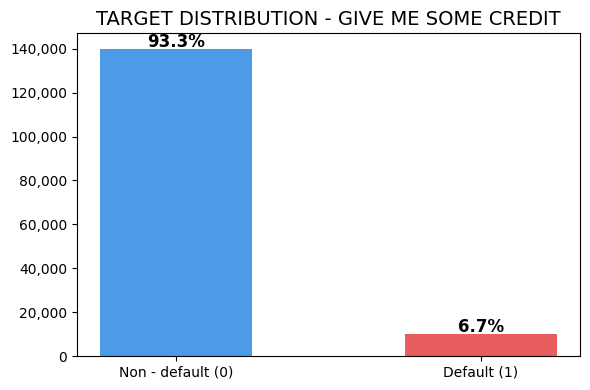

In [20]:

target_counts = df_gm['SeriousDlqin2yrs'].value_counts()
target_pct = df_gm['SeriousDlqin2yrs'].value_counts(normalize=True).mul(100).round(1)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    ['Non - default (0)', 'Default (1)'],
    target_counts.values,
    color=['#4C9BE8', '#E85D5D'],
    width=0.5
)

for bar, pct in zip(bars, target_pct.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1000,
        f'{pct}%',
        ha='center', fontsize=12, fontweight='bold'
    )

ax.set_title('TARGET DISTRIBUTION - GIVE ME SOME CREDIT', fontsize=14)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## A3. Split TRƯỚC feature engineering

QUAN TRỌNG: split trước để no-FE pipeline dùng cùng random state¶


In [21]:
X_gm_raw = df_gm[GMSC_RAW_COLS].copy()
y_gm     = df_gm[TARGET_GM].copy()

X_gm_train_raw, X_gm_test_raw, y_gm_train, y_gm_test = train_test_split(
    X_gm_raw, y_gm, test_size=0.2, random_state=RANDOM_SEED, stratify=y_gm)

print(f'Train: {X_gm_train_raw.shape} | Test: {X_gm_test_raw.shape}')
print(f'Bad rate — train: {y_gm_train.mean():.4f} | test: {y_gm_test.mean():.4f}')

n_good_gm = (y_gm_train == 0).sum()
n_bad_gm  = (y_gm_train == 1).sum()
bad_w_gm  = n_good_gm / n_bad_gm
print(f'Class weight (bad): {bad_w_gm:.2f}')

Train: (120000, 10) | Test: (30000, 10)
Bad rate — train: 0.0668 | test: 0.0668
Class weight (bad): 13.96


##  A4. Feature Engineering

In [22]:
df_gm_fe = df_gm[GMSC_RAW_COLS + [TARGET_GM]].copy()

df_gm_fe['TotalPastDue']      = (df_gm_fe['NumberOfTime30-59DaysPastDueNotWorse'] +
                                   df_gm_fe['NumberOfTime60-89DaysPastDueNotWorse'] +
                                   df_gm_fe['NumberOfTimes90DaysLate'])
df_gm_fe['WeightedPastDue']   = (df_gm_fe['NumberOfTime30-59DaysPastDueNotWorse'] * 1 +
                                   df_gm_fe['NumberOfTime60-89DaysPastDueNotWorse'] * 2 +
                                   df_gm_fe['NumberOfTimes90DaysLate'] * 3)
df_gm_fe['EverLate90']        = (df_gm_fe['NumberOfTimes90DaysLate'] > 0).astype(int)
df_gm_fe['EverLate60']        = (df_gm_fe['NumberOfTime60-89DaysPastDueNotWorse'] > 0).astype(int)
df_gm_fe['EverLate30']        = (df_gm_fe['NumberOfTime30-59DaysPastDueNotWorse'] > 0).astype(int)
df_gm_fe['SeverePastDueRatio']= df_gm_fe['NumberOfTimes90DaysLate'] / (df_gm_fe['TotalPastDue'] + 1)
df_gm_fe['MonthlyDebt']       = df_gm_fe['DebtRatio'] * df_gm_fe['MonthlyIncome']
df_gm_fe['DisposableIncome']  = df_gm_fe['MonthlyIncome'] - df_gm_fe['MonthlyDebt']
df_gm_fe['IncomePerDependent']= df_gm_fe['MonthlyIncome'] / (df_gm_fe['NumberOfDependents'] + 1)
df_gm_fe['TotalLoansAndLines']= (df_gm_fe['NumberOfOpenCreditLinesAndLoans'] +
                                   df_gm_fe['NumberRealEstateLoansOrLines'])
df_gm_fe['RealEstateRatio']   = (df_gm_fe['NumberRealEstateLoansOrLines'] /
                                   (df_gm_fe['TotalLoansAndLines'] + 1))
df_gm_fe['NoCreditLines']     = (df_gm_fe['NumberOfOpenCreditLinesAndLoans'] == 0).astype(int)
df_gm_fe['UtilizationXPastDue'] = (df_gm_fe['RevolvingUtilizationOfUnsecuredLines'] *
                                     df_gm_fe['TotalPastDue'])

print(f'FE: {len(GMSC_RAW_COLS)} raw → {df_gm_fe.shape[1]-1} total features')

# Re-split với cùng index (bảo đảm train/test split nhất quán)
X_gm_fe = df_gm_fe.drop(columns=[TARGET_GM])
X_gm_train_fe = X_gm_fe.loc[X_gm_train_raw.index].copy()
X_gm_test_fe  = X_gm_fe.loc[X_gm_test_raw.index].copy()

FE: 10 raw → 23 total features


## A5. Preprocessing — Baseline (impute → cap → WOE → scale)

In [23]:
X_gm_train_bl = X_gm_train_fe.copy()
X_gm_test_bl  = X_gm_test_fe.copy()

# Impute MonthlyIncome theo nhóm tuổi
X_gm_train_bl['_age_bin'] = pd.cut(X_gm_train_bl['age'],
    bins=[0,25,35,45,55,65,120]).astype(str)
X_gm_test_bl['_age_bin']  = pd.cut(X_gm_test_bl['age'],
    bins=[0,25,35,45,55,65,120]).astype(str)
X_gm_train_bl, X_gm_test_bl = impute_median_group(
    X_gm_train_bl, X_gm_test_bl, '_age_bin', 'MonthlyIncome')
X_gm_train_bl.drop(columns='_age_bin', inplace=True)
X_gm_test_bl.drop(columns='_age_bin',  inplace=True)
X_gm_train_bl, X_gm_test_bl = impute_all_numeric(X_gm_train_bl, X_gm_test_bl)

# Cap outliers
for col in ['NumberOfTime30-59DaysPastDueNotWorse',
            'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfTimes90DaysLate']:
    X_gm_train_bl[col] = X_gm_train_bl[col].clip(0, 20)
    X_gm_test_bl[col]  = X_gm_test_bl[col].clip(0, 20)
X_gm_train_bl['RevolvingUtilizationOfUnsecuredLines'] = \
    X_gm_train_bl['RevolvingUtilizationOfUnsecuredLines'].clip(0, 1.5)
X_gm_test_bl['RevolvingUtilizationOfUnsecuredLines']  = \
    X_gm_test_bl['RevolvingUtilizationOfUnsecuredLines'].clip(0, 1.5)
X_gm_train_bl, X_gm_test_bl = cap_iqr(X_gm_train_bl, X_gm_test_bl,
    skip_cols=['NumberOfTime30-59DaysPastDueNotWorse',
               'NumberOfTime60-89DaysPastDueNotWorse',
               'NumberOfTimes90DaysLate',
               'RevolvingUtilizationOfUnsecuredLines'])

# WOE + scale
X_gm_train_bl, X_gm_test_bl, woe_gm, scaler_gm = apply_woe_scale(
    X_gm_train_bl, X_gm_test_bl, y_gm_train)
print(f'Baseline input: train={X_gm_train_bl.shape} | test={X_gm_test_bl.shape}')

Baseline input: train=(120000, 23) | test=(30000, 23)


## A6. Baseline models 

A6. Baseline Models — Give Me Some Credit
  Training Logistic Regression ... (1.4s)
  [test] AUC=0.8654  Gini=0.7308  KS=0.5734  F1(bad)=0.3309
  [train] AUC=0.8600  Gini=0.7199  KS=0.5638  F1(bad)=0.3301
  Training Decision Tree ... (0.7s)
  [test] AUC=0.8548  Gini=0.7096  KS=0.5709  F1(bad)=0.3241
  [train] AUC=0.8632  Gini=0.7264  KS=0.5761  F1(bad)=0.3238
  Training Random Forest ... (13.8s)
  [test] AUC=0.8658  Gini=0.7316  KS=0.5824  F1(bad)=0.3341
  [train] AUC=0.8770  Gini=0.7539  KS=0.5992  F1(bad)=0.3403
  Training XGBoost ... (1.4s)
  [test] AUC=0.8500  Gini=0.7000  KS=0.5520  F1(bad)=0.3143
  [train] AUC=0.9442  Gini=0.8883  KS=0.7446  F1(bad)=0.4438
  Training LightGBM ... (0.9s)
  [test] AUC=0.8660  Gini=0.7321  KS=0.5786  F1(bad)=0.3277
  [train] AUC=0.9014  Gini=0.8029  KS=0.6319  F1(bad)=0.3613
  Training CatBoost ... (18.4s)
  [test] AUC=0.8570  Gini=0.7141  KS=0.5612  F1(bad)=0.3243
  [train] AUC=0.9344  Gini=0.8689  KS=0.7239  F1(bad)=0.4169


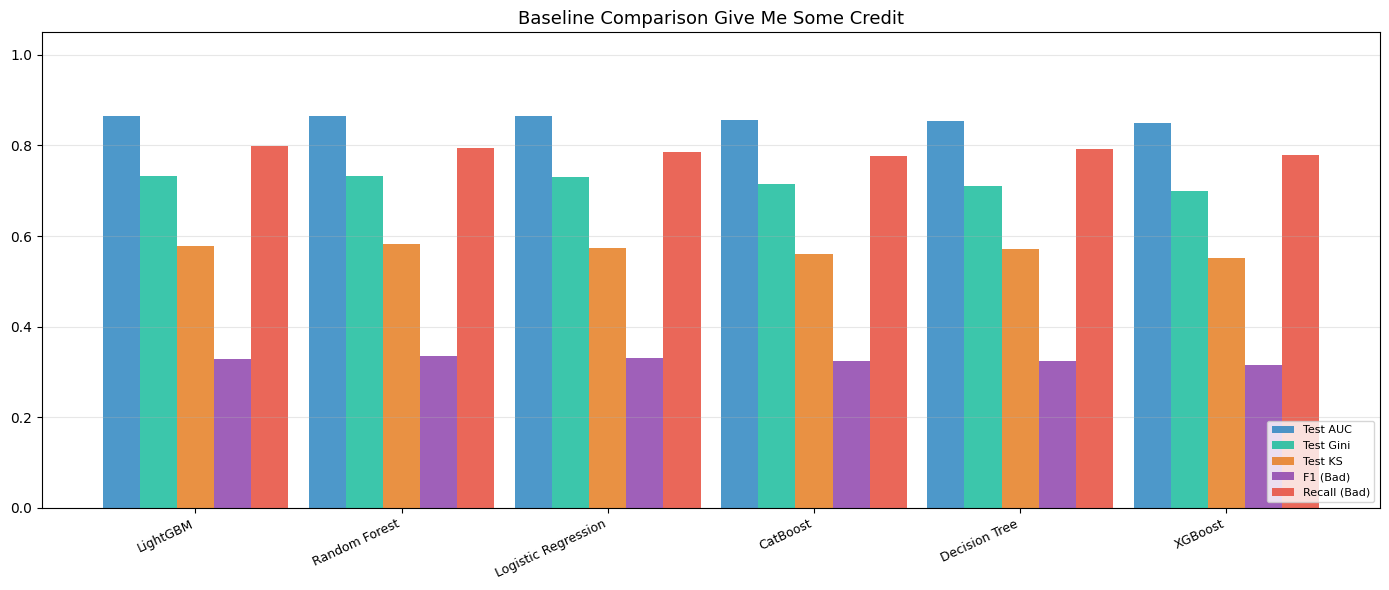

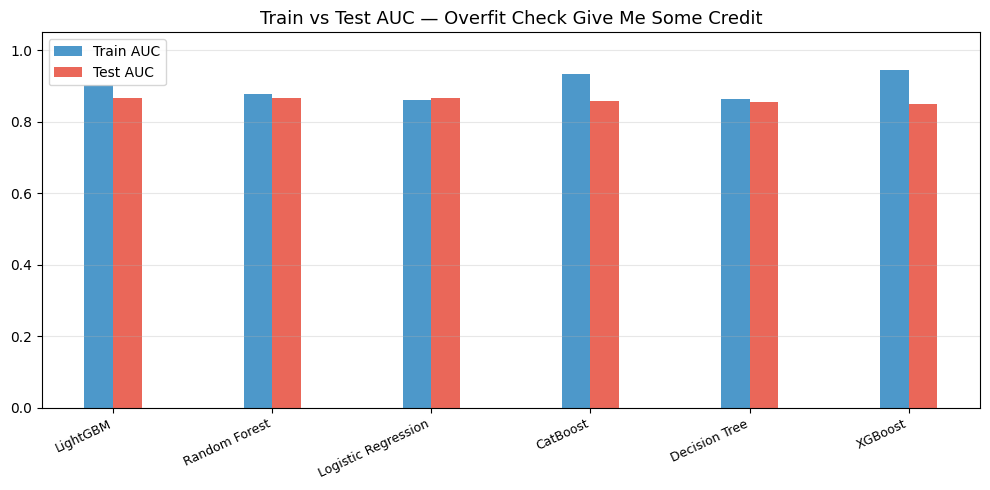

              Model  Train AUC  Test AUC  Test Gini  Test KS  F1 (Bad)
           LightGBM     0.9014    0.8660     0.7321   0.5786    0.3277
      Random Forest     0.8770    0.8658     0.7316   0.5824    0.3341
Logistic Regression     0.8600    0.8654     0.7308   0.5734    0.3309
           CatBoost     0.9344    0.8570     0.7141   0.5612    0.3243
      Decision Tree     0.8632    0.8548     0.7096   0.5709    0.3241
            XGBoost     0.9442    0.8500     0.7000   0.5520    0.3143


In [24]:
print('='*60)
print('A6. Baseline Models — Give Me Some Credit')
print('='*60)

models_gm    = build_baseline_models(bad_w_gm)
results_gm   = train_baseline_models(models_gm, X_gm_train_bl, X_gm_test_bl,
                                      y_gm_train, y_gm_test)
df_summary_gm = summarize_results(results_gm)
plot_baseline(df_summary_gm, title_suffix='Give Me Some Credit')
df_summary_gm.to_csv(f'{OUTPUT_DIR}/summary_gm_baseline.csv', index=False)
print(df_summary_gm[['Model','Train AUC','Test AUC','Test Gini','Test KS','F1 (Bad)']].to_string(index=False))

##  A7. TabNet without FE

In [25]:

print('='*60)
print('A7. TabNet WITHOUT Feature Engineering — Give Me Some Credit')
print('='*60)

X_raw_tr = X_gm_train_raw.copy()
X_raw_te = X_gm_test_raw.copy()
X_gm_train_nofe, X_gm_test_nofe, qt_gm_nofe = preprocess_for_tabnet(X_raw_tr, X_raw_te)
X_gm_nofe_tr_np = X_gm_train_nofe.values.astype(np.float32)
X_gm_nofe_te_np = X_gm_test_nofe.values.astype(np.float32)
print(f'\nNo-FE input: {X_gm_nofe_tr_np.shape[1]} features (raw only)')
print(f'With-FE input (for reference): {X_gm_train_bl.shape[1]} features')

class_w_gm = np.where(y_gm_train.values == 1, bad_w_gm, 1.0)

# ── A7a. TabNet DEFAULT (no FE) ──────────────────────────────
tabnet_gm_default = TabNetClassifier(
    device_name='auto', verbose=10, seed=42)

print('\nTraining TabNet default (no FE) ...')
t0 = time.time()
tabnet_gm_default.fit(
    X_gm_nofe_tr_np, y_gm_train.values.astype(np.int64),
    eval_set=[(X_gm_nofe_te_np, y_gm_test.values.astype(np.int64))],
    eval_name=['test'], eval_metric=['auc'],
    max_epochs=100, patience=15, batch_size=1024, virtual_batch_size=128,
    weights=class_w_gm, drop_last=False)
tabnet_gm_default_time = time.time() - t0

tabnet_gm_default_train = evaluate(tabnet_gm_default, X_gm_nofe_tr_np,
                                    y_gm_train.values.astype(np.int64), label='train')
tabnet_gm_default_test  = evaluate(tabnet_gm_default, X_gm_nofe_te_np,
                                    y_gm_test.values.astype(np.int64),  label='test')
df_summary_gm = append_to_summary(df_summary_gm, 'TabNet default (no FE)',
                                   tabnet_gm_default_train, tabnet_gm_default_test,
                                   train_time=round(tabnet_gm_default_time, 2))

# # ── A7b. TabNet OPTUNA (no FE) ───────────────────────────────
# tabnet_gm_nofe = TabNetClassifier(
#     n_d=64, n_a=64, n_steps=8, gamma=1.5,
#     n_independent=3, n_shared=3, lambda_sparse=1e-4,
#     optimizer_fn=torch.optim.Adam,
#     optimizer_params=dict(lr=2e-3, weight_decay=1e-5),
#     scheduler_fn=torch.optim.lr_scheduler.StepLR,
#     scheduler_params=dict(step_size=10, gamma=0.9),
#     mask_type='entmax', device_name='auto', verbose=10, seed=42)

# print('\nTraining TabNet Optuna (no FE) ...')
# t0 = time.time()
# tabnet_gm_nofe.fit(
#     X_gm_nofe_tr_np, y_gm_train.values.astype(np.int64),
#     eval_set=[(X_gm_nofe_te_np, y_gm_test.values.astype(np.int64))],
#     eval_name=['test'], eval_metric=['auc'],
#     max_epochs=100, patience=15, batch_size=1024, virtual_batch_size=128,
#     weights=class_w_gm, drop_last=False)
# tabnet_gm_nofe_time = time.time() - t0

# tabnet_gm_nofe_train = evaluate(tabnet_gm_nofe, X_gm_nofe_tr_np,
#                                   y_gm_train.values.astype(np.int64), label='train')
# tabnet_gm_nofe_test  = evaluate(tabnet_gm_nofe, X_gm_nofe_te_np,
#                                   y_gm_test.values.astype(np.int64),  label='test')
# df_summary_gm = append_to_summary(df_summary_gm, 'TabNet Optuna (no FE)',
#                                    tabnet_gm_nofe_train, tabnet_gm_nofe_test,
#                                    train_time=round(tabnet_gm_nofe_time, 2))

A7. TabNet WITHOUT Feature Engineering — Give Me Some Credit
  TabNet input: train=(120000, 10) | test=(30000, 10)

No-FE input: 10 features (raw only)
With-FE input (for reference): 23 features

Training TabNet default (no FE) ...
epoch 0  | loss: 0.50991 | test_auc: 0.85044 |  0:00:06s
epoch 10 | loss: 0.4648  | test_auc: 0.86415 |  0:00:55s
epoch 20 | loss: 0.46241 | test_auc: 0.86366 |  0:01:46s

Early stopping occurred at epoch 22 with best_epoch = 7 and best_test_auc = 0.86621
  [train] AUC=0.8648  Gini=0.7296  KS=0.5727  F1(bad)=0.3336
  [test] AUC=0.8662  Gini=0.7324  KS=0.5778  F1(bad)=0.3402


In [26]:
# # A7c. Improved TabNet MHA (no FE)
# bp_gm_nofe = {
#     'n_d': 96, 'n_steps': 5, 'n_heads': 4, 'd_model': 64,
#     'gamma': 1.5, 'lambda_sparse': 0.001, 'focal_gamma': 2.0,
#     'dropout': 0.19, 'lr': 0.0028, 'weight_decay': 1.16e-05,  # 'wd' → 'weight_decay'
#     'batch_size': 512,
# }

# print('\nTraining Improved TabNet MHA (no FE) ...')
# mha_gm_nofe_wrapper, mha_gm_nofe_train, mha_gm_nofe_test, mha_gm_nofe_hist, \
#     mha_gm_nofe_raw, _ = train_improved_tabnet(
#         X_gm_train_nofe, X_gm_test_nofe, y_gm_train, y_gm_test, bad_w_gm,
#         **{k: bp_gm_nofe[k] for k in
#            ['n_d','n_steps','n_heads','d_model','gamma','lambda_sparse',
#             'focal_gamma','dropout','lr','weight_decay','batch_size']},
#         max_epochs=150, patience=20,
#     )

# df_summary_gm = append_to_summary(df_summary_gm, 'Improved TabNet (no FE)',
#                                     mha_gm_nofe_train, mha_gm_nofe_test)

# print(df_summary_gm[['Model','Train AUC','Test AUC','Test Gini','Test KS','F1 (Bad)']].to_string(index=False))

## A8. TabNet with FE

In [27]:
print('='*60)
print('A8. TabNet WITH Feature Engineering — Give Me Some Credit')
print('='*60)

# Preprocessing TabNet với FE features
X_gm_train_fe_prep = X_gm_train_fe.copy()
X_gm_test_fe_prep  = X_gm_test_fe.copy()
X_gm_train_fe_prep['_age_bin'] = pd.cut(X_gm_train_fe_prep['age'],
    bins=[0,25,35,45,55,65,120]).astype(str)
X_gm_test_fe_prep['_age_bin']  = pd.cut(X_gm_test_fe_prep['age'],
    bins=[0,25,35,45,55,65,120]).astype(str)
X_gm_train_fe_prep, X_gm_test_fe_prep = impute_median_group(
    X_gm_train_fe_prep, X_gm_test_fe_prep, '_age_bin', 'MonthlyIncome')
X_gm_train_fe_prep.drop(columns='_age_bin', inplace=True)
X_gm_test_fe_prep.drop(columns='_age_bin',  inplace=True)
X_gm_train_fe_prep, X_gm_test_fe_prep = impute_all_numeric(
    X_gm_train_fe_prep, X_gm_test_fe_prep)
X_gm_train_tn, X_gm_test_tn, qt_gm = preprocess_for_tabnet(
    X_gm_train_fe_prep, X_gm_test_fe_prep)

X_gm_fe_tr_np = X_gm_train_tn.values.astype(np.float32)
X_gm_fe_te_np = X_gm_test_tn.values.astype(np.float32)
class_w_gm    = np.where(y_gm_train.values == 1, bad_w_gm, 1.0)

print(f'\nWith-FE input: {X_gm_fe_tr_np.shape[1]} features')
print(f'No-FE input (for reference): {X_gm_nofe_tr_np.shape[1]} features')


# ── A8a. TabNet DEFAULT (with FE) ────────────────────────────
tabnet_gm_fe_default = TabNetClassifier(
    device_name='auto', verbose=10, seed=42)

print('\nTraining TabNet default (with FE) ...')
t0 = time.time()
tabnet_gm_fe_default.fit(
    X_gm_fe_tr_np, y_gm_train.values.astype(np.int64),
    eval_set=[(X_gm_fe_te_np, y_gm_test.values.astype(np.int64))],
    eval_name=['test'], eval_metric=['auc'],
    max_epochs=100, patience=15, batch_size=1024, virtual_batch_size=128,
    weights=class_w_gm, drop_last=False)
tabnet_gm_fe_default_time = time.time() - t0

tabnet_gm_fe_default_train = evaluate(tabnet_gm_fe_default, X_gm_fe_tr_np,
                                       y_gm_train.values.astype(np.int64), label='train')
tabnet_gm_fe_default_test  = evaluate(tabnet_gm_fe_default, X_gm_fe_te_np,
                                       y_gm_test.values.astype(np.int64),  label='test')
df_summary_gm = append_to_summary(df_summary_gm, 'TabNet default (with FE)',
                                   tabnet_gm_fe_default_train, tabnet_gm_fe_default_test,
                                   train_time=round(tabnet_gm_fe_default_time, 2))

# # ── A8b. TabNet OPTUNA (with FE) ─────────────────────────────
# tabnet_gm_fe_optuna = TabNetClassifier(
#     n_d=bp_gm['n_d'], n_a=bp_gm['n_d'],
#     n_steps=bp_gm['n_steps'], gamma=bp_gm['gamma'],
#     lambda_sparse=bp_gm['lambda_sparse'],
#     optimizer_fn=torch.optim.Adam,
#     optimizer_params=dict(lr=bp_gm['lr'], weight_decay=bp_gm['wd']),
#     mask_type='entmax', device_name='auto', verbose=10, seed=42)

# print('\nTraining TabNet Optuna (with FE) ...')
# t0 = time.time()
# tabnet_gm_fe_optuna.fit(
#     X_gm_fe_tr_np, y_gm_train.values.astype(np.int64),
#     eval_set=[(X_gm_fe_te_np, y_gm_test.values.astype(np.int64))],
#     eval_name=['test'], eval_metric=['auc'],
#     max_epochs=100, patience=15, batch_size=bp_gm['batch_size'], virtual_batch_size=128,
#     weights=class_w_gm, drop_last=False)
# tabnet_gm_fe_optuna_time = time.time() - t0

# tabnet_gm_fe_optuna_train = evaluate(tabnet_gm_fe_optuna, X_gm_fe_tr_np,
#                                       y_gm_train.values.astype(np.int64), label='train')
# tabnet_gm_fe_optuna_test  = evaluate(tabnet_gm_fe_optuna, X_gm_fe_te_np,
#                                       y_gm_test.values.astype(np.int64),  label='test')
# df_summary_gm = append_to_summary(df_summary_gm, 'TabNet Optuna (with FE)',
#                                    tabnet_gm_fe_optuna_train, tabnet_gm_fe_optuna_test,
#                                    train_time=round(tabnet_gm_fe_optuna_time, 2))



A8. TabNet WITH Feature Engineering — Give Me Some Credit
  TabNet input: train=(120000, 23) | test=(30000, 23)

With-FE input: 23 features
No-FE input (for reference): 10 features

Training TabNet default (with FE) ...
epoch 0  | loss: 0.51016 | test_auc: 0.84982 |  0:00:06s
epoch 10 | loss: 0.46583 | test_auc: 0.86513 |  0:00:56s
epoch 20 | loss: 0.46213 | test_auc: 0.86715 |  0:01:49s
epoch 30 | loss: 0.45727 | test_auc: 0.86721 |  0:02:37s
epoch 40 | loss: 0.45384 | test_auc: 0.86676 |  0:03:26s

Early stopping occurred at epoch 49 with best_epoch = 34 and best_test_auc = 0.86803
  [train] AUC=0.8699  Gini=0.7397  KS=0.5832  F1(bad)=0.3594
  [test] AUC=0.8680  Gini=0.7361  KS=0.5802  F1(bad)=0.3491


In [28]:
df_summary_gm

,Model,Train AUC,Test AUC,Test Gini,Test KS,Precision (Bad),Recall (Bad),Recall (Good),F1 (Bad),TP,FP,TN,FN,Threshold,Train Time (s)
0,TabNet default (with FE),0.8699,0.8680,0.7361,0.5802,0.2258,0.7691,0.8111,0.3491,1542,5288,22707,463,0.5460,252.58
1,TabNet default (no FE),0.8648,0.8662,0.7324,0.5778,0.2177,0.7781,0.7997,0.3402,1560,5607,22388,445,0.5105,122.82
2,LightGBM,0.9014,0.8660,0.7321,0.5786,0.2062,0.7990,0.7796,0.3277,1602,6169,21826,403,0.4552,0.88
3,Random Forest,0.8770,0.8658,0.7316,0.5824,0.2116,0.7945,0.7879,0.3341,1593,5937,22058,412,0.4500,13.76
4,Logistic Regression,0.8600,0.8654,0.7308,0.5734,0.2096,0.7855,0.7878,0.3309,1575,5940,22055,430,0.4889,1.37
5,CatBoost,0.9344,0.8570,0.7141,0.5612,0.2049,0.7771,0.7841,0.3243,1558,6044,21951,447,0.4110,18.38
6,Decision Tree,0.8632,0.8548,0.7096,0.5709,0.2037,0.7930,0.7779,0.3241,1590,6217,21778,415,0.5232,0.75
7,XGBoost,0.9442,0.8500,0.7000,0.5520,0.1968,0.7800,0.7720,0.3143,1564,6384,21611,441,0.3792,1.36


In [29]:
# ── A8b. Improved TabNet MHA OPTUNA (with FE) ────────────────
# ── Optuna — Give Me Some Credit ─────────────────────────────
# print('='*60)
# print('Optuna Tuning — Give Me Some Credit')
# print('='*60)
# study_gm = run_optuna(
#     X_gm_fe_tr_np, X_gm_fe_te_np,
#     y_gm_train.values, y_gm_test.values,
#     bad_weight=bad_w_gm,
#     n_features=X_gm_fe_tr_np.shape[1],
#     n_trials=50
# )
# bp_gm = study_gm.best_params
# print('Best params GMSC:', bp_gm)

bp_gm = {'n_d': 96, 'n_steps': 8, 'n_heads': 4, 'd_model': 64, 'gamma': 1.3, 'lambda_sparse': 0.0001, 'focal_gamma': 2.0, 'dropout': 0.21803388685146963, 'lr': 0.001967745288261344, 'wd': 2.9872741995638434e-06, 'batch_size': 512}
print('\nTraining Improved TabNet MHA (with FE) ...')
mha_gm_wrapper, mha_gm_train, mha_gm_test, mha_gm_hist, mha_gm_raw, mha_gm_dev = \
    train_improved_tabnet(
        X_gm_train_tn, X_gm_test_tn, y_gm_train, y_gm_test, bad_w_gm,
        n_d=bp_gm['n_d'], n_steps=bp_gm['n_steps'], n_heads=bp_gm['n_heads'],
        d_model=bp_gm['d_model'], gamma=bp_gm['gamma'],
        lambda_sparse=bp_gm['lambda_sparse'], focal_gamma=bp_gm['focal_gamma'],
        dropout=bp_gm['dropout'], lr=bp_gm['lr'], weight_decay=bp_gm['wd'],
        batch_size=bp_gm['batch_size'], max_epochs=200, patience=30, warmup_epochs=10)
df_summary_gm = append_to_summary(df_summary_gm, 'Improved TabNet MHA (with FE)',
                                   mha_gm_train, mha_gm_test)
df_summary_gm


Training Improved TabNet MHA (with FE) ...
    Epoch   1 | test_auc=0.86095 | 6s
    Epoch  10 | test_auc=0.86338 | 59s
    Epoch  20 | test_auc=0.86768 | 117s
    Epoch  30 | test_auc=0.86606 | 176s
    Epoch  40 | test_auc=0.85914 | 234s
    Early stop @ epoch 44 | best=0.86927
  [train] AUC=0.8692  Gini=0.7384  KS=0.5840  F1(bad)=0.3423
  [test] AUC=0.8693  Gini=0.7385  KS=0.5821  F1(bad)=0.3386
  Done 258.7s | Train AUC=0.8692 | Test AUC=0.8693 | Gap=-0.0000


,Model,Train AUC,Test AUC,Test Gini,Test KS,Precision (Bad),Recall (Bad),Recall (Good),F1 (Bad),TP,FP,TN,FN,Threshold,Train Time (s)
0,Improved TabNet MHA (with FE),0.8692,0.8693,0.7385,0.5821,0.2157,0.7870,0.7951,0.3386,1578,5737,22258,427,0.5596,NaN
1,TabNet default (with FE),0.8699,0.8680,0.7361,0.5802,0.2258,0.7691,0.8111,0.3491,1542,5288,22707,463,0.5460,252.58
2,TabNet default (no FE),0.8648,0.8662,0.7324,0.5778,0.2177,0.7781,0.7997,0.3402,1560,5607,22388,445,0.5105,122.82
3,LightGBM,0.9014,0.8660,0.7321,0.5786,0.2062,0.7990,0.7796,0.3277,1602,6169,21826,403,0.4552,0.88
4,Random Forest,0.8770,0.8658,0.7316,0.5824,0.2116,0.7945,0.7879,0.3341,1593,5937,22058,412,0.4500,13.76
5,Logistic Regression,0.8600,0.8654,0.7308,0.5734,0.2096,0.7855,0.7878,0.3309,1575,5940,22055,430,0.4889,1.37
6,CatBoost,0.9344,0.8570,0.7141,0.5612,0.2049,0.7771,0.7841,0.3243,1558,6044,21951,447,0.4110,18.38
7,Decision Tree,0.8632,0.8548,0.7096,0.5709,0.2037,0.7930,0.7779,0.3241,1590,6217,21778,415,0.5232,0.75
8,XGBoost,0.9442,0.8500,0.7000,0.5520,0.1968,0.7800,0.7720,0.3143,1564,6384,21611,441,0.3792,1.36


In [30]:
# print('=' * 55)
# print('WEIGHTED BLEND — Give Me Some Credit')
# print('=' * 55)

# prob_gm = {
#     'TabNet':   mha_gm_wrapper.predict_proba(X_gm_fe_te_np)[:, 1],
#     'LightGBM': results_gm['LightGBM']['model'].predict_proba(X_gm_test_bl)[:, 1],
#     'CatBoost': results_gm['CatBoost']['model'].predict_proba(X_gm_test_bl)[:, 1],
# }
# y_gm_np = y_gm_test.values.astype(np.int64)

# print('\nAUC từng model:')
# for name, p in prob_gm.items():
#     print(f'  {name:<12} {roc_auc_score(y_gm_np, p):.4f}')

# print('\nGrid search trọng số (step=0.05) ...')
# best_w_gm, blend_auc_gm = grid_blend(prob_gm, y_gm_np, step=0.05)

# print(f'\nTrọng số tối ưu:')
# for n, w in best_w_gm.items():
#     print(f'  {n:<12} {w:.2f}')
# print(f'\nTest AUC TabNet alone : {roc_auc_score(y_gm_np, prob_gm["TabNet"]):.4f}')
# print(f'Test AUC Blend        : {blend_auc_gm:.4f}  '
#       f'(+{blend_auc_gm - roc_auc_score(y_gm_np, prob_gm["TabNet"]):+.4f})')

# blended_gm = blend_predict(prob_gm, best_w_gm)


# blended_gm_train = blend_predict(
#     {'TabNet':   mha_gm_wrapper.predict_proba(X_gm_fe_tr_np)[:, 1],
#      'LightGBM': results_gm['LightGBM']['model'].predict_proba(X_gm_train_bl)[:, 1],
#      'CatBoost': results_gm['CatBoost']['model'].predict_proba(X_gm_train_bl)[:, 1]},
#     best_w_gm
# )
# gm_tr_m = metrics_from_prob(y_gm_train.values, blended_gm_train)
# gm_te_m = metrics_from_prob(y_gm_np, blended_gm)

# df_summary_gm = append_to_summary(
#     df_summary_gm, 'Weighted Blend (TabNet+LGBM+CB)', gm_tr_m, gm_te_m)

# df_summary_gm

## A9. SHAP analysis 

SHAP Analysis — Give Me Some Credit


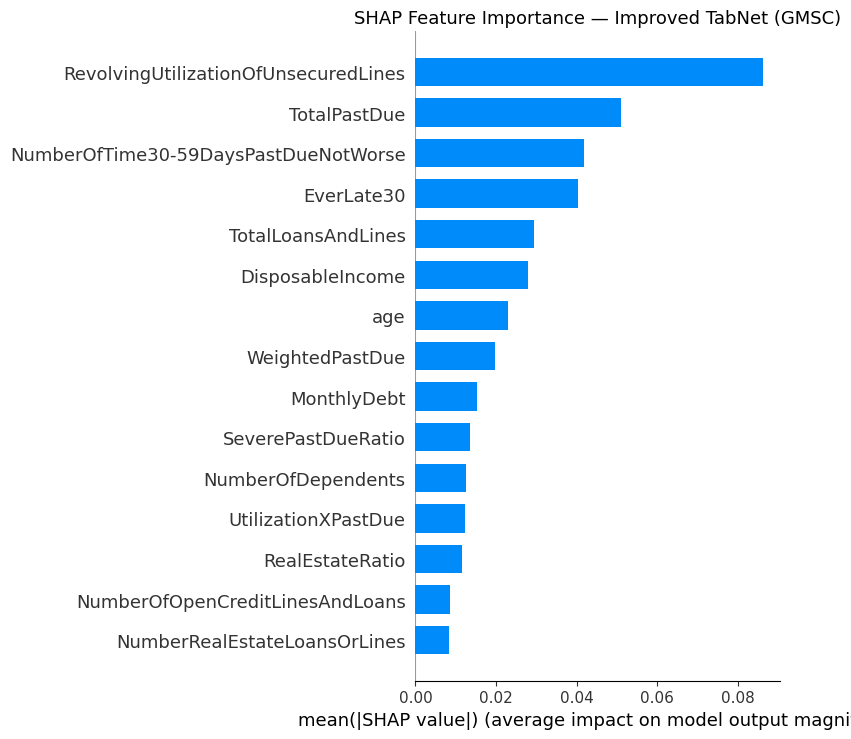

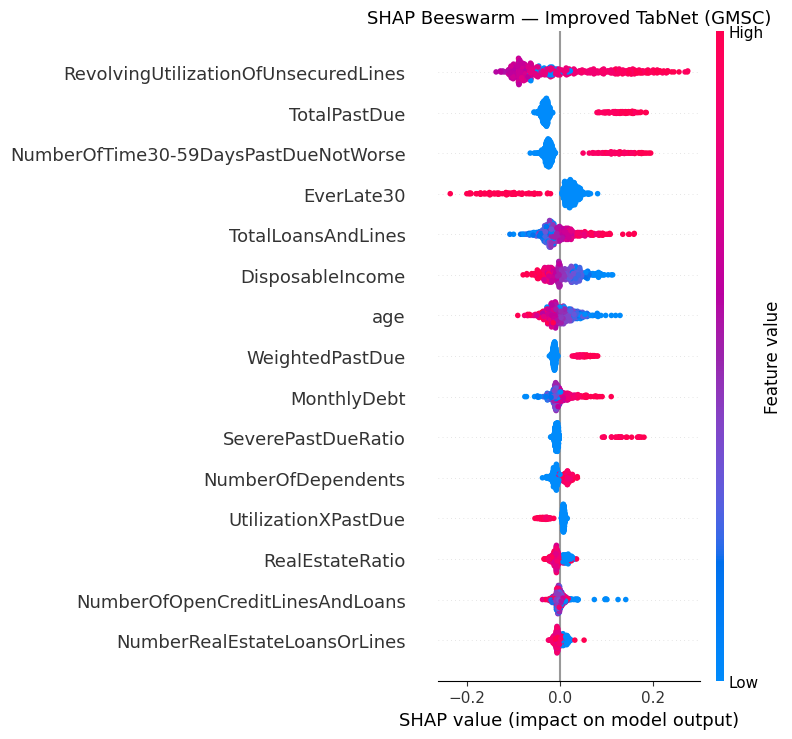

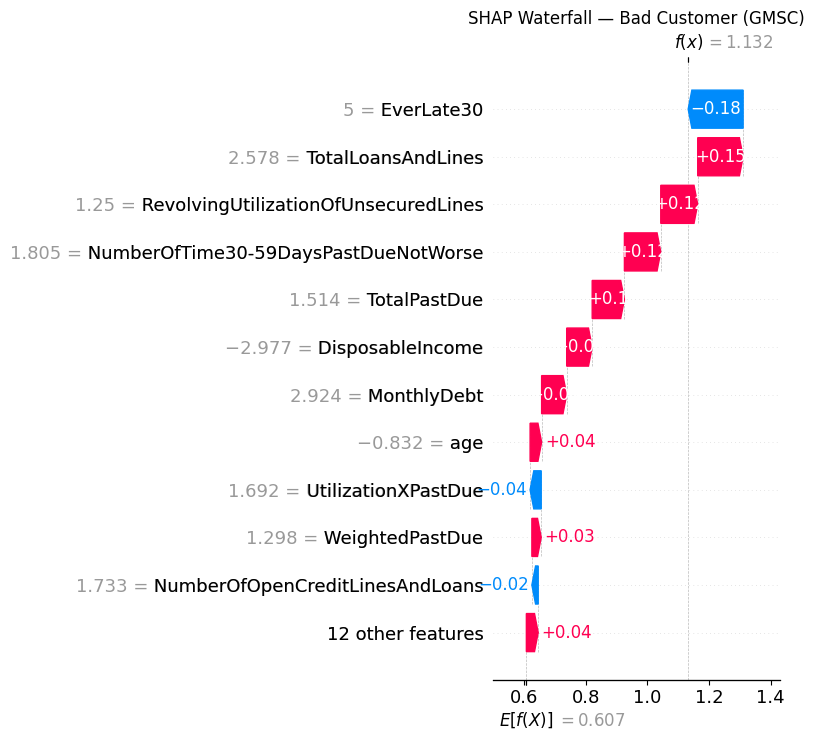

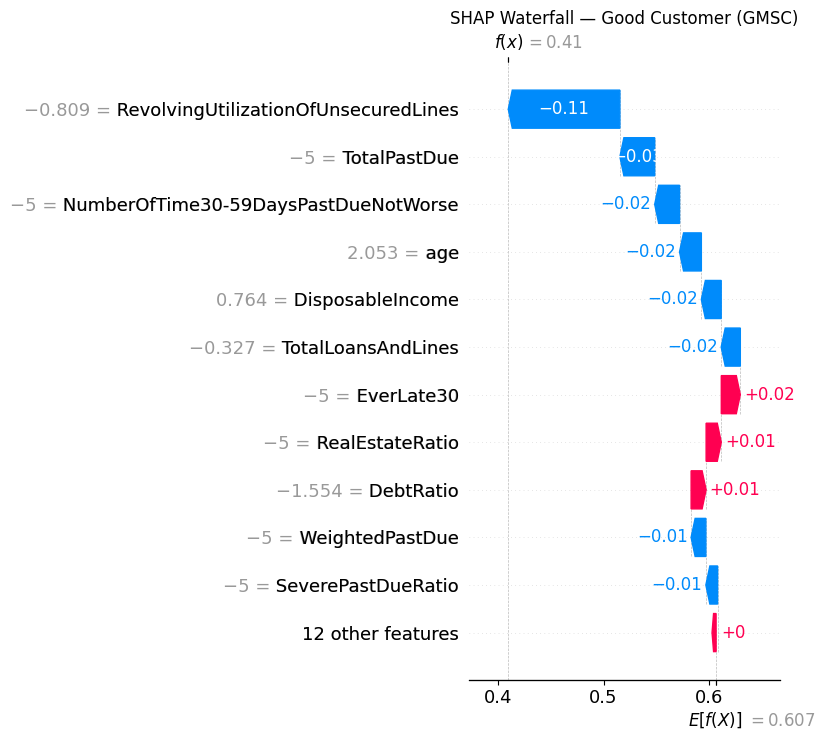


Top 10 SHAP features (GMSC):
RevolvingUtilizationOfUnsecuredLines    0.086161
TotalPastDue                            0.050971
NumberOfTime30-59DaysPastDueNotWorse    0.041716
EverLate30                              0.040314
TotalLoansAndLines                      0.029500
DisposableIncome                        0.027872
age                                     0.022971
WeightedPastDue                         0.019662
MonthlyDebt                             0.015316
SeverePastDueRatio                      0.013511


In [31]:
print('='*60)
print('SHAP Analysis — Give Me Some Credit')
print('='*60)

shap.initjs()

sv_gm, mean_shap_gm = run_shap_analysis(
    model_raw   = mha_gm_raw,
    X_train_np  = X_gm_fe_tr_np,
    X_test_np   = X_gm_fe_te_np,
    y_test_np   = y_gm_test.values.astype(np.int64),
    feat_names  = list(X_gm_train_tn.columns),
    tag         = 'GMSC',
)

# PHẦN B - Home Credit Dataset

## B1. Load data

In [32]:
# Load data
app = pd.read_csv('/kaggle/input/competitions/home-credit-default-risk/application_train.csv')
prev = pd.read_csv('/kaggle/input/competitions/home-credit-default-risk/previous_application.csv')

# Aggregate previous_application theo SK_ID_CURR
prev_agg = prev.groupby('SK_ID_CURR').agg(
    prev_count                = ('SK_ID_PREV',          'count'),
    prev_amt_credit_mean      = ('AMT_CREDIT',          'mean'),
    prev_amt_credit_max       = ('AMT_CREDIT',          'max'),
    prev_amt_annuity_mean     = ('AMT_ANNUITY',         'mean'),
    prev_amt_application_mean = ('AMT_APPLICATION',     'mean'),
    prev_days_decision_mean   = ('DAYS_DECISION',       'mean'),
    prev_approved_count       = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Approved').sum()),
    prev_refused_count        = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Refused').sum()),
    prev_cnt_payment_mean     = ('CNT_PAYMENT',         'mean'),
).reset_index()

# Tỉ lệ approved
prev_agg['prev_approval_rate'] = (
    prev_agg['prev_approved_count'] / prev_agg['prev_count']
)

# Merge vào application
df_merge = app.merge(prev_agg, on='SK_ID_CURR', how='left')

In [33]:
df = df_merge.copy()

# Fill NaN cho khách hàng không có lịch sử vay trước
# prev_cols = [c for c in prev_agg.columns if c != 'SK_ID_CURR']
# df[prev_cols] = df[prev_cols].fillna(0)

# Thay vì fillna(0) cho tất cả, chỉ fill count = 0
# còn rate/ratio fill = -1 để phân biệt "không có lịch sử"
df['prev_count'] = df['prev_count'].fillna(0)
df['prev_approval_rate'] = df['prev_approval_rate'].fillna(-1)  # -1 = không có lịch sử
df['prev_approved_count'] = df['prev_approved_count'].fillna(0)
df['prev_refused_count']  = df['prev_refused_count'].fillna(0)
# các cột amount fill median thay vì 0
for col in ['prev_amt_credit_mean', 'prev_amt_credit_max', 
            'prev_amt_annuity_mean', 'prev_amt_application_mean',
            'prev_days_decision_mean', 'prev_cnt_payment_mean']:
    df[col] = df[col].fillna(df[col].median())


print(df.shape)
print(df[['SK_ID_CURR', 'TARGET', 'prev_count', 'prev_approval_rate']].head())

(307511, 132)
   SK_ID_CURR  TARGET  prev_count  prev_approval_rate
0      100002       1         1.0            1.000000
1      100003       0         3.0            1.000000
2      100004       0         1.0            1.000000
3      100006       0         9.0            0.555556
4      100007       0         6.0            1.000000


In [34]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,prev_count,prev_amt_credit_mean,prev_amt_credit_max,prev_amt_annuity_mean,prev_amt_application_mean,prev_days_decision_mean,prev_approved_count,prev_refused_count,prev_cnt_payment_mean,prev_approval_rate
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,179055.00,179055.0,9251.775,179055.00,-606.000000,1.0,0.0,24.000000,1.000000
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,484191.00,1035882.0,56553.990,435436.50,-1305.000000,3.0,0.0,10.000000,1.000000
2,100004,0,Revolving loans,M,Y,Y,0,67

In [35]:
drop_cols = [
    # Flag document: hầu hết gần 0, correlation với target cực thấp
    'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3','FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5','FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7',
    'FLAG_DOCUMENT_8','FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12',
    'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16','FLAG_DOCUMENT_17','FLAG_DOCUMENT_18',
    'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21',

    # Contact flags: variance thấp, ít phân biệt
    'FLAG_MOBIL',        # 99.9% = 1, vô nghĩa
    'FLAG_CONT_MOBILE',  # tương tự

    # Address mismatch ở region level — city level đã đủ
    'REG_REGION_NOT_LIVE_REGION',
    'REG_REGION_NOT_WORK_REGION',
    'LIVE_REGION_NOT_WORK_REGION',

    # Thời điểm nộp đơn — ít signal
    'WEEKDAY_APPR_PROCESS_START',
    'HOUR_APPR_PROCESS_START',
]

df.drop(columns=drop_cols, inplace=True)
print(f"Còn lại: {df.shape} ")

Còn lại: (307511, 105) 


In [36]:
# Xóa cột có null cao
null_thresh = 0.5
null_cols = df.columns[df.isnull().mean() > null_thresh].tolist()
print(f'Xóa {len(null_cols)} cột null >{null_thresh*100:.0f}%: {null_cols}')
df.drop(columns=null_cols, inplace=True)

Xóa 41 cột null >50%: ['OWN_CAR_AGE', 'EXT_SOURCE_1', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE']


In [37]:

df.shape

(307511, 64)

## B2. EDA

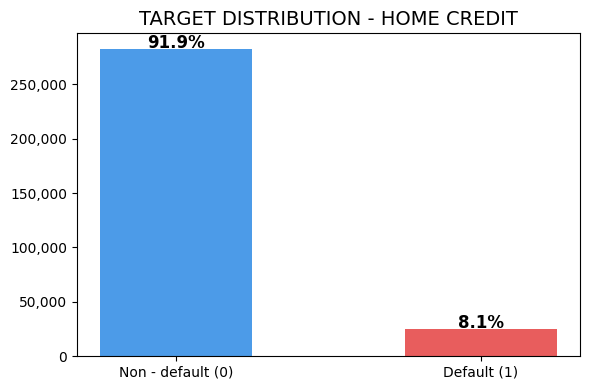

In [38]:
import matplotlib.pyplot as plt

target_counts = df['TARGET'].value_counts()
target_pct = df['TARGET'].value_counts(normalize=True).mul(100).round(1)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    ['Non - default (0)', 'Default (1)'],
    target_counts.values,
    color=['#4C9BE8', '#E85D5D'],
    width=0.5
)

for bar, pct in zip(bars, target_pct.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1000,
        f'{pct}%',
        ha='center', fontsize=12, fontweight='bold'
    )

ax.set_title('TARGET DISTRIBUTION - HOME CREDIT', fontsize=14)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## B3. Split TRƯỚC

In [39]:
HC_RAW_COLS = [c for c in df.columns if c != 'TARGET']

X_raw = df[HC_RAW_COLS].copy()
y     = df['TARGET'].copy()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)

print(f'Train: {X_train_raw.shape} | Test: {X_test_raw.shape}')
print(f'Bad rate — train: {y_train.mean():.4f} | test: {y_test.mean():.4f}')

n_good = (y_train == 0).sum()
n_bad  = (y_train == 1).sum()
bad_w  = n_good / n_bad
print(f'Class weight (bad): {bad_w:.2f}')

Train: (246008, 63) | Test: (61503, 63)
Bad rate — train: 0.0807 | test: 0.0807
Class weight (bad): 11.39


##  B4. Feature Engineering

In [40]:
# ── Feature Engineering: tạo biến mới ─────────────────────────────

# 1. Tỉ lệ & ratio tài chính
df['CREDIT_INCOME_RATIO']     = df['AMT_CREDIT'] / (df['AMT_INCOME_TOTAL'] + 1)
df['ANNUITY_INCOME_RATIO']    = df['AMT_ANNUITY'] / (df['AMT_INCOME_TOTAL'] + 1)
df['CREDIT_TERM']             = df['AMT_ANNUITY'] / (df['AMT_CREDIT'] + 1)
df['GOODS_CREDIT_RATIO']      = df['AMT_GOODS_PRICE'] / (df['AMT_CREDIT'] + 1)
df['INCOME_PER_PERSON']       = df['AMT_INCOME_TOTAL'] / (df['CNT_FAM_MEMBERS'] + 1)
df['CHILDREN_RATIO']          = df['CNT_CHILDREN'] / (df['CNT_FAM_MEMBERS'] + 1)

# 2. Tuổi & thâm niên
df['AGE_YEARS']               = df['DAYS_BIRTH'] / -365
df['EMPLOYED_YEARS']          = df['DAYS_EMPLOYED'].clip(upper=0) / -365  # clip loại outlier 365243
df['EMPLOYED_TO_AGE_RATIO']   = df['EMPLOYED_YEARS'] / (df['AGE_YEARS'] + 1)
df['ID_PUBLISH_YEARS']        = df['DAYS_ID_PUBLISH'] / -365
df['REGISTRATION_YEARS']      = df['DAYS_REGISTRATION'] / -365
df['PHONE_CHANGE_YEARS']      = df['DAYS_LAST_PHONE_CHANGE'] / -365


# 3. Social circle risk
df['SOCIAL_DEF_RATE_30']      = df['DEF_30_CNT_SOCIAL_CIRCLE'] / (df['OBS_30_CNT_SOCIAL_CIRCLE'] + 1)
df['SOCIAL_DEF_RATE_60']      = df['DEF_60_CNT_SOCIAL_CIRCLE'] / (df['OBS_60_CNT_SOCIAL_CIRCLE'] + 1)

# 4. Credit bureau enquiries
df['AMT_REQ_CREDIT_TOTAL']    = (
    df['AMT_REQ_CREDIT_BUREAU_HOUR'] +
    df['AMT_REQ_CREDIT_BUREAU_DAY']  +
    df['AMT_REQ_CREDIT_BUREAU_WEEK'] +
    df['AMT_REQ_CREDIT_BUREAU_MON']  +
    df['AMT_REQ_CREDIT_BUREAU_QRT']  +
    df['AMT_REQ_CREDIT_BUREAU_YEAR']
)

# 5. Previous application features
df['PREV_CREDIT_DIFF']        = df['prev_amt_credit_mean'] - df['prev_amt_application_mean']
df['PREV_CREDIT_APP_RATIO']   = df['prev_amt_credit_mean'] / (df['prev_amt_application_mean'] + 1)

# thêm
df['PREV_APPROVAL_RATIO'] = df['prev_approved_count'] / (df['prev_count'] + 1)
df['PREV_REFUSED_RATIO']  = df['prev_refused_count']  / (df['prev_count'] + 1)


new_features = [
    'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_TERM', 'GOODS_CREDIT_RATIO',
    'INCOME_PER_PERSON', 'CHILDREN_RATIO',
    'AGE_YEARS', 'EMPLOYED_YEARS', 'EMPLOYED_TO_AGE_RATIO',
    'ID_PUBLISH_YEARS', 'REGISTRATION_YEARS', 'PHONE_CHANGE_YEARS',

    'SOCIAL_DEF_RATE_30', 'SOCIAL_DEF_RATE_60',
    'AMT_REQ_CREDIT_TOTAL',
    'PREV_CREDIT_DIFF', 'PREV_CREDIT_APP_RATIO',
    'PREV_APPROVAL_RATIO', 'PREV_REFUSED_RATIO'

]

print(f"Đã tạo {len(new_features)} features mới")
print(f"Shape mới: {df.shape}")

# Re-split với cùng index (bảo đảm train/test split nhất quán)
X_fe = df.drop(columns=['TARGET'])
X_train_fe = X_fe.loc[X_train_raw.index].copy()
X_test_fe  = X_fe.loc[X_test_raw.index].copy()

Đã tạo 19 features mới
Shape mới: (307511, 83)


## B5. Preprocessing — Baseline (impute → cap → WOE → scale)

In [41]:
X_train_bl = X_train_fe.copy()
X_test_bl  = X_test_fe.copy()


# Impute AMT_INCOME_TOTAL theo nhóm tuổi
X_train_bl['_age_bin'] = pd.cut(X_train_bl['AGE_YEARS'],
    bins=[0,25,35,45,55,65,120]).astype(str)
X_test_bl['_age_bin']  = pd.cut(X_test_bl['AGE_YEARS'],
    bins=[0,25,35,45,55,65,120]).astype(str)
X_train_bl, X_test_bl = impute_median_group(
    X_train_bl, X_test_bl, '_age_bin', 'AMT_INCOME_TOTAL')
X_train_bl.drop(columns='_age_bin', inplace=True)
X_test_bl.drop(columns='_age_bin',  inplace=True)

# Impute toàn bộ numeric còn lại
X_train_bl, X_test_bl = impute_all_numeric(X_train_bl, X_test_bl)

# Cap outliers
X_train_bl, X_test_bl = cap_iqr(X_train_bl, X_test_bl)

# WOE + scale
X_train_bl, X_test_bl, woe_hc, scaler_hc = apply_woe_scale(
    X_train_bl, X_test_bl, y_train)

print(f'Baseline input: train={X_train_bl.shape} | test={X_test_bl.shape}')

Baseline input: train=(246008, 82) | test=(61503, 82)


## B6. Baseline models

A6. Baseline Models — Home Credit
  Training Logistic Regression ... (5.5s)
  [test] AUC=0.7544  Gini=0.5089  KS=0.3816  F1(bad)=0.2626
  [train] AUC=0.7533  Gini=0.5066  KS=0.3789  F1(bad)=0.2619
  Training Decision Tree ... (6.7s)
  [test] AUC=0.7172  Gini=0.4345  KS=0.3208  F1(bad)=0.2340
  [train] AUC=0.7238  Gini=0.4476  KS=0.3293  F1(bad)=0.2461
  Training Random Forest ... (74.9s)
  [test] AUC=0.7494  Gini=0.4988  KS=0.3778  F1(bad)=0.2662
  [train] AUC=0.7795  Gini=0.5590  KS=0.4199  F1(bad)=0.2705
  Training XGBoost ... (4.5s)
  [test] AUC=0.7529  Gini=0.5059  KS=0.3790  F1(bad)=0.2534
  [train] AUC=0.8852  Gini=0.7704  KS=0.6137  F1(bad)=0.3696
  Training LightGBM ... (5.9s)
  [test] AUC=0.7675  Gini=0.5350  KS=0.4011  F1(bad)=0.2705
  [train] AUC=0.8061  Gini=0.6123  KS=0.4584  F1(bad)=0.2862
  Training CatBoost ... (51.5s)
  [test] AUC=0.7637  Gini=0.5273  KS=0.3961  F1(bad)=0.2699
  [train] AUC=0.8970  Gini=0.7940  KS=0.6444  F1(bad)=0.3824


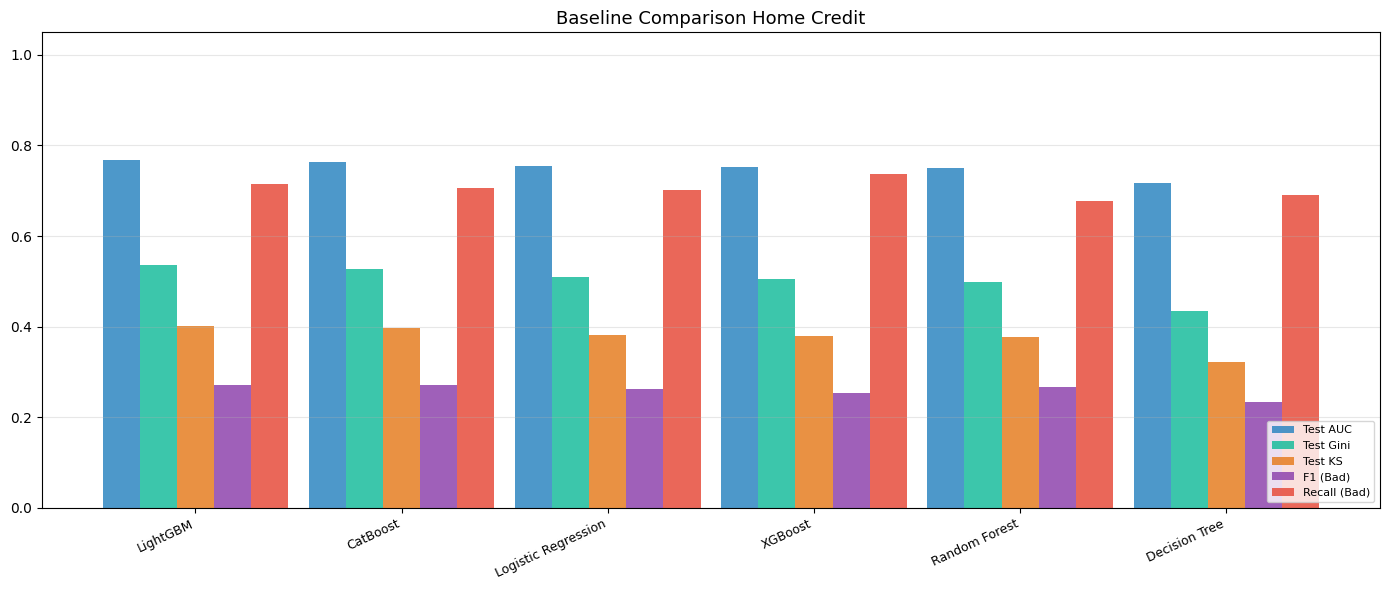

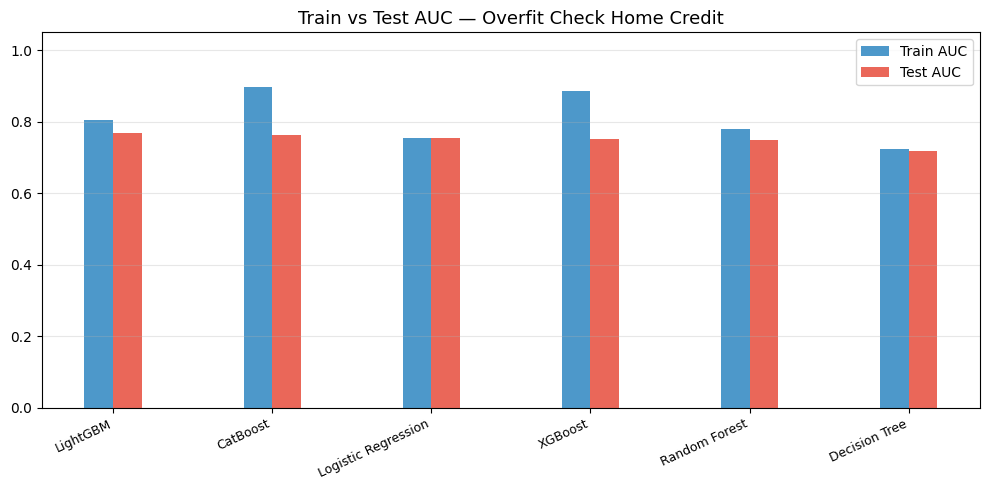

,Model,Train AUC,Test AUC,Test Gini,Test KS,Precision (Bad),Recall (Bad),Recall (Good),F1 (Bad),TP,FP,TN,FN,Threshold,Train Time (s)
0,LightGBM,0.8061,0.7675,0.5350,0.4011,0.1668,0.7144,0.6867,0.2705,3547,17716,38822,1418,0.4810,5.91
1,CatBoost,0.8970,0.7637,0.5273,0.3961,0.1668,0.7055,0.6906,0.2699,3503,17494,39044,1462,0.4223,51.52
2,Logistic Regression,0.7533,0.7544,0.5089,0.3816,0.1615,0.7013,0.6803,0.2626,3482,18077,38461,1483,0.4900,5.46
3,XGBoost,0.8852,0.7529,0.5059,0.3790,0.1530,0.7378,0.6413,0.2534,3663,20281,36257,1302,0.3885,4.51
4,Random Forest,0.7795,0.7494,0.4988,0.3778,0.1657,0.6773,0.7004,0.2662,3363,16936,39602,1602,0.4888,74.85
5,Decision Tree,0.7238,0.7172,0.4345,0.3208,0.1408,0.6910,0.6298,0.2340,3431,20933,35605,1534,0.4810,6.74


In [42]:
print('='*60)
print('A6. Baseline Models — Home Credit')
print('='*60)
models_hc     = build_baseline_models(bad_w)
results_hc    = train_baseline_models(models_hc, X_train_bl, X_test_bl,
                                       y_train, y_test)
df_summary_hc = summarize_results(results_hc)
plot_baseline(df_summary_hc, title_suffix='Home Credit')
# df_summary_hc.to_csv(f'{OUTPUT_DIR}/summary_hc_baseline.csv', index=False)
df_summary_hc

In [43]:
X_train_bl.shape

(246008, 82)

## B7. Tabnet without FE

In [44]:
print('='*60)
print('A7. TabNet WITHOUT Feature Engineering — Home Credit')
print('='*60)
X_raw_tr = X_train_raw.copy()
X_raw_te = X_test_raw.copy()
X_train_nofe, X_test_nofe, qt_hc_nofe = preprocess_for_tabnet(X_raw_tr, X_raw_te)
X_nofe_tr_np = X_train_nofe.values.astype(np.float32)
X_nofe_te_np = X_test_nofe.values.astype(np.float32)
print(f'\nNo-FE input: {X_nofe_tr_np.shape[1]} features (raw only)')
print(f'With-FE input (for reference): {X_train_bl.shape[1]} features')

class_w_hc = np.where(y_train.values == 1, bad_w, 1.0)

# ── A7a. TabNet DEFAULT (no FE) ──────────────────────────────
tabnet_hc_default = TabNetClassifier(
    device_name='auto', verbose=10, seed=42)
print('\nTraining TabNet default (no FE) ...')
t0 = time.time()
tabnet_hc_default.fit(
    X_nofe_tr_np, y_train.values.astype(np.int64),
    eval_set=[(X_nofe_te_np, y_test.values.astype(np.int64))],
    eval_name=['test'], eval_metric=['auc'],
    max_epochs=100, patience=15, batch_size=1024, virtual_batch_size=128,
    weights=class_w_hc, drop_last=False)
tabnet_hc_default_time = time.time() - t0

tabnet_hc_default_train = evaluate(tabnet_hc_default, X_nofe_tr_np,
                                    y_train.values.astype(np.int64), label='train')
tabnet_hc_default_test  = evaluate(tabnet_hc_default, X_nofe_te_np,
                                    y_test.values.astype(np.int64),  label='test')
df_summary_hc = append_to_summary(df_summary_hc, 'TabNet default (no FE)',
                                   tabnet_hc_default_train, tabnet_hc_default_test,
                                   train_time=round(tabnet_hc_default_time, 2))
df_summary_hc

A7. TabNet WITHOUT Feature Engineering — Home Credit
  TabNet input: train=(246008, 63) | test=(61503, 63)

No-FE input: 63 features (raw only)
With-FE input (for reference): 82 features

Training TabNet default (no FE) ...
epoch 0  | loss: 0.64633 | test_auc: 0.71549 |  0:00:10s
epoch 10 | loss: 0.6035  | test_auc: 0.74266 |  0:01:54s
epoch 20 | loss: 0.58158 | test_auc: 0.75756 |  0:03:38s
epoch 30 | loss: 0.57142 | test_auc: 0.75315 |  0:05:22s

Early stopping occurred at epoch 32 with best_epoch = 17 and best_test_auc = 0.75846
  [train] AUC=0.7611  Gini=0.5221  KS=0.3891  F1(bad)=0.2662
  [test] AUC=0.7585  Gini=0.5169  KS=0.3855  F1(bad)=0.2719


,Model,Train AUC,Test AUC,Test Gini,Test KS,Precision (Bad),Recall (Bad),Recall (Good),F1 (Bad),TP,FP,TN,FN,Threshold,Train Time (s)
0,LightGBM,0.8061,0.7675,0.5350,0.4011,0.1668,0.7144,0.6867,0.2705,3547,17716,38822,1418,0.4810,5.91
1,CatBoost,0.8970,0.7637,0.5273,0.3961,0.1668,0.7055,0.6906,0.2699,3503,17494,39044,1462,0.4223,51.52
2,TabNet default (no FE),0.7611,0.7585,0.5169,0.3855,0.1703,0.6737,0.7118,0.2719,3345,16294,40244,1620,0.5090,362.65
3,Logistic Regression,0.7533,0.7544,0.5089,0.3816,0.1615,0.7013,0.6803,0.2626,3482,18077,38461,1483,0.4900,5.46
4,XGBoost,0.8852,0.7529,0.5059,0.3790,0.1530,0.7378,0.6413,0.2534,3663,20281,36257,1302,0.3885,4.51
5,Random Forest,0.7795,0.7494,0.4988,0.3778,0.1657,0.6773,0.7004,0.2662,3363,16936,39602,1602,0.4888,74.85
6,Decision Tree,0.7238,0.7172,0.4345,0.3208,0.1408,0.6910,0.6298,0.2340,3431,20933,35605,1534,0.4810,6.74


## B8. TabNet with FE

In [45]:
print('='*60)
print('A8. TabNet WITH Feature Engineering — Home Credit')
print('='*60)

# Preprocessing TabNet với FE features
X_train_fe_prep = X_train_fe.copy()
X_test_fe_prep  = X_test_fe.copy()
X_train_fe_prep['_age_bin'] = pd.cut(X_train_fe_prep['AGE_YEARS'],
    bins=[0,25,35,45,55,65,120]).astype(str)
X_test_fe_prep['_age_bin']  = pd.cut(X_test_fe_prep['AGE_YEARS'],
    bins=[0,25,35,45,55,65,120]).astype(str)
X_train_fe_prep, X_test_fe_prep = impute_median_group(
    X_train_fe_prep, X_test_fe_prep, '_age_bin', 'AMT_INCOME_TOTAL')
X_train_fe_prep.drop(columns='_age_bin', inplace=True)
X_test_fe_prep.drop(columns='_age_bin',  inplace=True)
X_train_fe_prep, X_test_fe_prep = impute_all_numeric(
    X_train_fe_prep, X_test_fe_prep)
X_train_tn, X_test_tn, qt_hc = preprocess_for_tabnet(
    X_train_fe_prep, X_test_fe_prep)

X_fe_tr_np = X_train_tn.values.astype(np.float32)
X_fe_te_np = X_test_tn.values.astype(np.float32)
class_w_hc = np.where(y_train.values == 1, bad_w, 1.0)

print(f'\nWith-FE input: {X_fe_tr_np.shape[1]} features')
print(f'No-FE input (for reference): {X_nofe_tr_np.shape[1]} features')

A8. TabNet WITH Feature Engineering — Home Credit
  TabNet input: train=(246008, 82) | test=(61503, 82)

With-FE input: 82 features
No-FE input (for reference): 63 features


In [46]:


# ── A8a. TabNet DEFAULT (with FE) ────────────────────────────
tabnet_hc_fe_default = TabNetClassifier(
    device_name='auto', verbose=10, seed=42)

print('\nTraining TabNet default (with FE) ...')
t0 = time.time()
tabnet_hc_fe_default.fit(
    X_fe_tr_np, y_train.values.astype(np.int64),
    eval_set=[(X_fe_te_np, y_test.values.astype(np.int64))],
    eval_name=['test'], eval_metric=['auc'],
    max_epochs=100, patience=15, batch_size=1024, virtual_batch_size=128,
    weights=class_w_hc, drop_last=False)
tabnet_hc_fe_default_time = time.time() - t0

tabnet_hc_fe_default_train = evaluate(tabnet_hc_fe_default, X_fe_tr_np,
                                       y_train.values.astype(np.int64), label='train')
tabnet_hc_fe_default_test  = evaluate(tabnet_hc_fe_default, X_fe_te_np,
                                       y_test.values.astype(np.int64),  label='test')
df_summary_hc = append_to_summary(df_summary_hc, 'TabNet default (with FE)',
                                   tabnet_hc_fe_default_train, tabnet_hc_fe_default_test,
                                   train_time=round(tabnet_hc_fe_default_time, 2))



Training TabNet default (with FE) ...
epoch 0  | loss: 0.65189 | test_auc: 0.71632 |  0:00:10s
epoch 10 | loss: 0.57787 | test_auc: 0.75437 |  0:01:54s
epoch 20 | loss: 0.55886 | test_auc: 0.7501  |  0:03:39s

Early stopping occurred at epoch 23 with best_epoch = 8 and best_test_auc = 0.75538
  [train] AUC=0.7671  Gini=0.5342  KS=0.3965  F1(bad)=0.2652
  [test] AUC=0.7554  Gini=0.5108  KS=0.3806  F1(bad)=0.2644


In [47]:
df_summary_hc

,Model,Train AUC,Test AUC,Test Gini,Test KS,Precision (Bad),Recall (Bad),Recall (Good),F1 (Bad),TP,FP,TN,FN,Threshold,Train Time (s)
0,LightGBM,0.8061,0.7675,0.5350,0.4011,0.1668,0.7144,0.6867,0.2705,3547,17716,38822,1418,0.4810,5.91
1,CatBoost,0.8970,0.7637,0.5273,0.3961,0.1668,0.7055,0.6906,0.2699,3503,17494,39044,1462,0.4223,51.52
2,TabNet default (no FE),0.7611,0.7585,0.5169,0.3855,0.1703,0.6737,0.7118,0.2719,3345,16294,40244,1620,0.5090,362.65
3,TabNet default (with FE),0.7671,0.7554,0.5108,0.3806,0.1634,0.6914,0.6892,0.2644,3433,17573,38965,1532,0.5179,273.63
4,Logistic Regression,0.7533,0.7544,0.5089,0.3816,0.1615,0.7013,0.6803,0.2626,3482,18077,38461,1483,0.4900,5.46
5,XGBoost,0.8852,0.7529,0.5059,0.3790,0.1530,0.7378,0.6413,0.2534,3663,20281,36257,1302,0.3885,4.51
6,Random Forest,0.7795,0.7494,0.4988,0.3778,0.1657,0.6773,0.7004,0.2662,3363,16936,39602,1602,0.4888,74.85
7,Decision Tree,0.7238,0.7172,0.4345,0.3208,0.1408,0.6910,0.6298,0.2340,3431,20933,35605,1534,0.4810,6.74


In [48]:

# ── A8b. Improved TabNet MHA OPTUNA (with FE) ────────────────
# ── Optuna — Home Credit ──────────────────────────────────────
# print('='*60)
# print('Optuna Tuning — Home Credit')
# print('='*60)
# study_hc = run_optuna(
#     X_fe_tr_np, X_fe_te_np,
#     y_train.values, y_test.values,
#     bad_weight=bad_w,
#     n_features=X_fe_tr_np.shape[1],
#     n_trials=20          # giảm xuống 20 vì HC 300k dòng, tránh timeout Kaggle
# )
# bp_hc = study_hc.best_params
# print('Best params HC:', bp_hc)

bp_hc = {'n_d': 96, 'n_steps': 7, 'n_heads': 8, 'd_model': 128, 'gamma': 1.3, 'lambda_sparse': 0.0001, 'focal_gamma': 1.0, 'dropout': 0.22745912116761546, 'lr': 0.0037356890409918015, 'wd': 8.038364275114193e-06, 'batch_size': 512}


print('\nTraining Improved TabNet MHA (with FE) ...')
mha_hc_wrapper, mha_hc_train, mha_hc_test, mha_hc_hist, mha_hc_raw, mha_hc_dev = \
    train_improved_tabnet(
        X_train_tn, X_test_tn, y_train, y_test, bad_w,
        n_d=bp_hc['n_d'], n_steps=bp_hc['n_steps'], n_heads=bp_hc['n_heads'],
        d_model=bp_hc['d_model'], gamma=bp_hc['gamma'],
        lambda_sparse=bp_hc['lambda_sparse'], focal_gamma=bp_hc['focal_gamma'],
        dropout=bp_hc['dropout'], lr=bp_hc['lr'], weight_decay=bp_hc['wd'],
        batch_size=bp_hc['batch_size'], max_epochs=150, patience=20)
df_summary_hc = append_to_summary(df_summary_hc, 'Improved TabNet MHA (with FE)',
                                   mha_hc_train, mha_hc_test)
df_summary_hc


Training Improved TabNet MHA (with FE) ...
    Epoch   1 | test_auc=0.75646 | 40s
    Epoch  10 | test_auc=0.74984 | 376s
    Epoch  20 | test_auc=0.70135 | 751s
    Early stop @ epoch 24 | best=0.76137
  [train] AUC=0.7699  Gini=0.5397  KS=0.4057  F1(bad)=0.2748
  [test] AUC=0.7614  Gini=0.5227  KS=0.3938  F1(bad)=0.2732
  Done 916.5s | Train AUC=0.7699 | Test AUC=0.7614 | Gap=0.0085


,Model,Train AUC,Test AUC,Test Gini,Test KS,Precision (Bad),Recall (Bad),Recall (Good),F1 (Bad),TP,FP,TN,FN,Threshold,Train Time (s)
0,LightGBM,0.8061,0.7675,0.5350,0.4011,0.1668,0.7144,0.6867,0.2705,3547,17716,38822,1418,0.4810,5.91
1,CatBoost,0.8970,0.7637,0.5273,0.3961,0.1668,0.7055,0.6906,0.2699,3503,17494,39044,1462,0.4223,51.52
2,Improved TabNet MHA (with FE),0.7699,0.7614,0.5227,0.3938,0.1704,0.6878,0.7060,0.2732,3415,16624,39914,1550,0.5410,NaN
3,TabNet default (no FE),0.7611,0.7585,0.5169,0.3855,0.1703,0.6737,0.7118,0.2719,3345,16294,40244,1620,0.5090,362.65
4,TabNet default (with FE),0.7671,0.7554,0.5108,0.3806,0.1634,0.6914,0.6892,0.2644,3433,17573,38965,1532,0.5179,273.63
5,Logistic Regression,0.7533,0.7544,0.5089,0.3816,0.1615,0.7013,0.6803,0.2626,3482,18077,38461,1483,0.4900,5.46
6,XGBoost,0.8852,0.7529,0.5059,0.3790,0.1530,0.7378,0.6413,0.2534,3663,20281,36257,1302,0.3885,4.51
7,Random Forest,0.7795,0.7494,0.4988,0.3778,0.1657,0.6773,0.7004,0.2662,3363,16936,39602,1602,0.4888,74.85
8,Decision Tree,0.7238,0.7172,0.4345,0.3208,0.1408,0.6910,0.6298,0.2340,3431,20933,35605,1534,0.4810,6.74


In [49]:


# # ─────────────────────────────────────────────────────────────
# # 2. HOME CREDIT
# # ─────────────────────────────────────────────────────────────

# print('\n' + '=' * 55)
# print('WEIGHTED BLEND — Home Credit')
# print('=' * 55)

# prob_hc = {
#     'TabNet':   mha_hc_wrapper.predict_proba(X_fe_te_np)[:, 1],
#     'LightGBM': results_hc['LightGBM']['model'].predict_proba(X_test_bl)[:, 1],
#     'CatBoost': results_hc['CatBoost']['model'].predict_proba(X_test_bl)[:, 1],
# }
# y_hc_np = y_test.values.astype(np.int64)

# print('\nAUC từng model:')
# for name, p in prob_hc.items():
#     print(f'  {name:<12} {roc_auc_score(y_hc_np, p):.4f}')

# print('\nGrid search trọng số (step=0.05) ...')
# best_w_hc, blend_auc_hc = grid_blend(prob_hc, y_hc_np, step=0.05)

# print(f'\nTrọng số tối ưu:')
# for n, w in best_w_hc.items():
#     print(f'  {n:<12} {w:.2f}')
# print(f'\nTest AUC TabNet alone : {roc_auc_score(y_hc_np, prob_hc["TabNet"]):.4f}')
# print(f'Test AUC Blend        : {blend_auc_hc:.4f}  '
#       f'(+{blend_auc_hc - roc_auc_score(y_hc_np, prob_hc["TabNet"]):+.4f})')

# blended_hc = blend_predict(prob_hc, best_w_hc)

# blended_hc_train = blend_predict(
#     {'TabNet':   mha_hc_wrapper.predict_proba(X_fe_tr_np)[:, 1],
#      'LightGBM': results_hc['LightGBM']['model'].predict_proba(X_train_bl)[:, 1],
#      'CatBoost': results_hc['CatBoost']['model'].predict_proba(X_train_bl)[:, 1]},
#     best_w_hc
# )
# hc_tr_m = metrics_from_prob(y_train.values, blended_hc_train)
# hc_te_m = metrics_from_prob(y_hc_np, blended_hc)

# df_summary_hc = append_to_summary(
#     df_summary_hc, 'Weighted Blend (TabNet+LGBM+CB)', hc_tr_m, hc_te_m)

# df_summary_hc




## B9. SHAP

SHAP Analysis — Home Credit


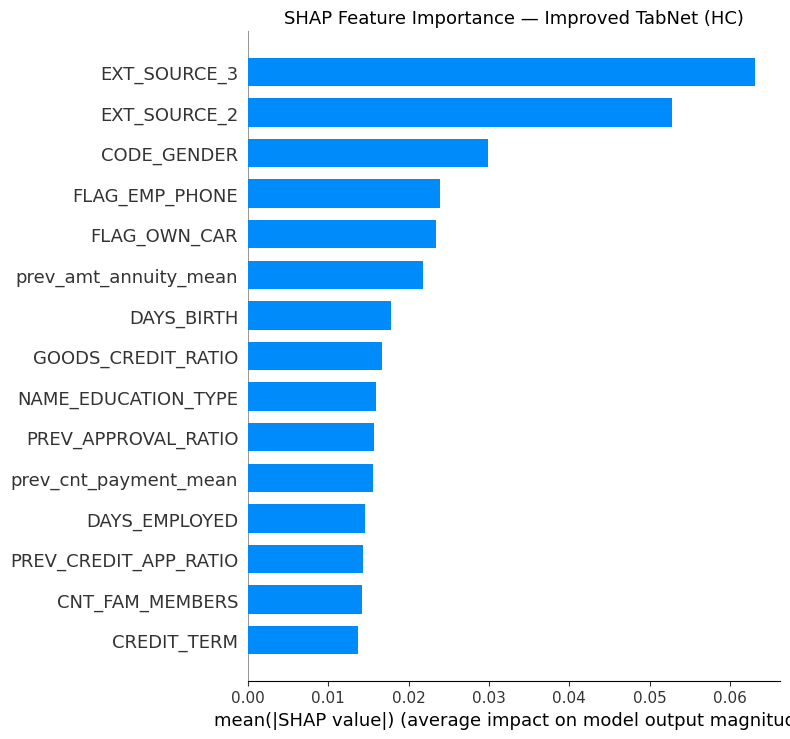

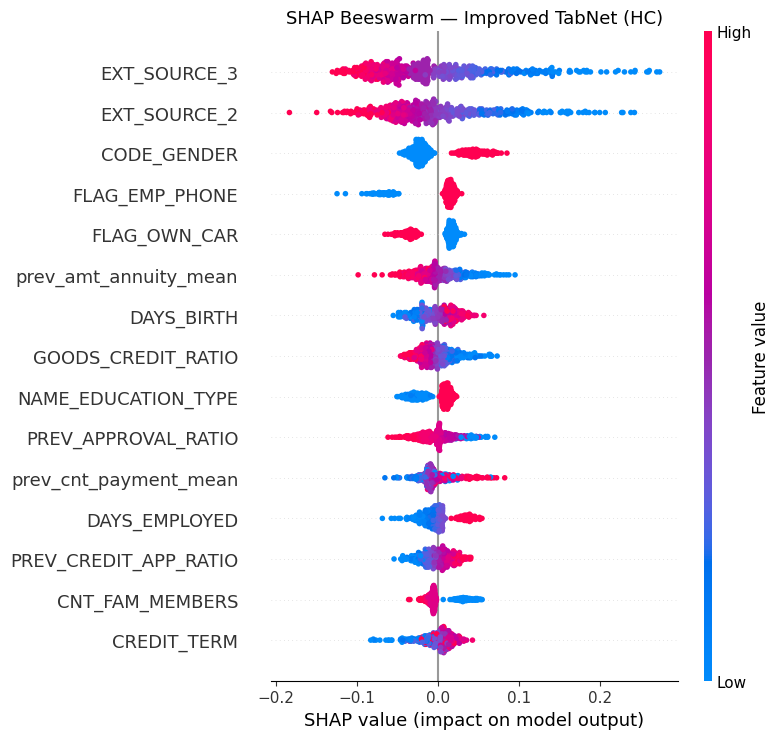

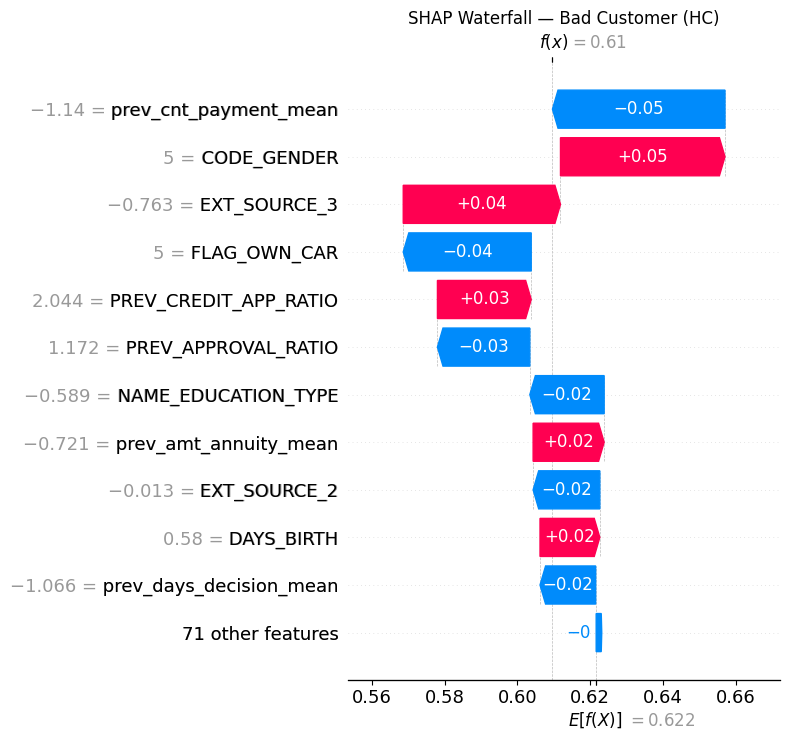

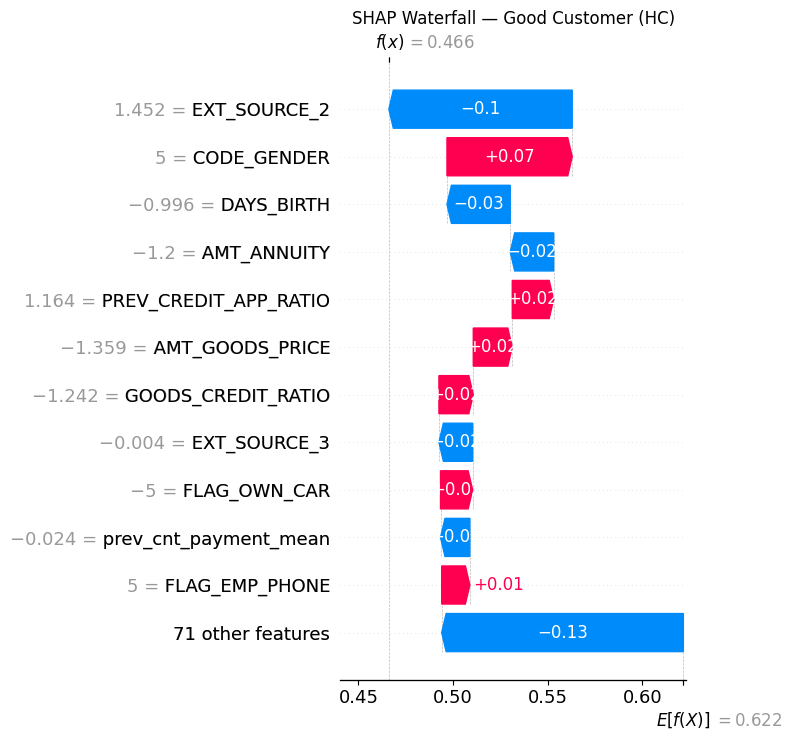


Top 10 SHAP features (HC):
EXT_SOURCE_3             0.063095
EXT_SOURCE_2             0.052852
CODE_GENDER              0.029869
FLAG_EMP_PHONE           0.023943
FLAG_OWN_CAR             0.023423
prev_amt_annuity_mean    0.021800
DAYS_BIRTH               0.017778
GOODS_CREDIT_RATIO       0.016656
NAME_EDUCATION_TYPE      0.015978
PREV_APPROVAL_RATIO      0.015747


In [50]:
print('='*60)
print('SHAP Analysis — Home Credit')
print('='*60)

sv_hc, mean_shap_hc = run_shap_analysis(
    model_raw   = mha_hc_raw,
    X_train_np  = X_fe_tr_np,
    X_test_np   = X_fe_te_np,
    y_test_np   = y_test.values.astype(np.int64),
    feat_names  = list(X_train_tn.columns),
    tag         = 'HC',
)

# PHẦN C - THỐNG KÊ & BÁO CÁO


── Risk Tiering (Give Me Some Credit) ──
            tier  Count  Bad_Rate  Avg_Prob  Bad_Rate_pct
 Medium (10–30%)   9298  0.005162  0.248956          0.52
   High (30–50%)  11058  0.023512  0.388446          2.35
Very High (>50%)   9644  0.175964  0.674077         17.60


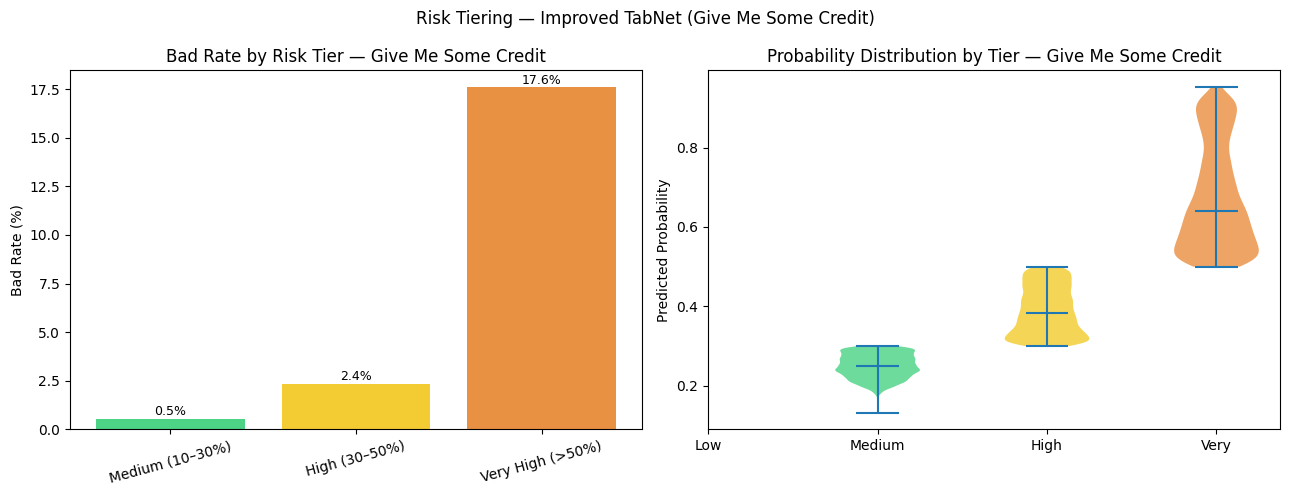


── Risk Tiering (Home Credit) ──
            tier  Count  Bad_Rate  Avg_Prob  Bad_Rate_pct
     Low (0–10%)      7  0.000000  0.082417          0.00
 Medium (10–30%)   6037  0.014245  0.251870          1.42
   High (30–50%)  30676  0.037097  0.403783          3.71
Very High (>50%)  24783  0.150950  0.649335         15.10


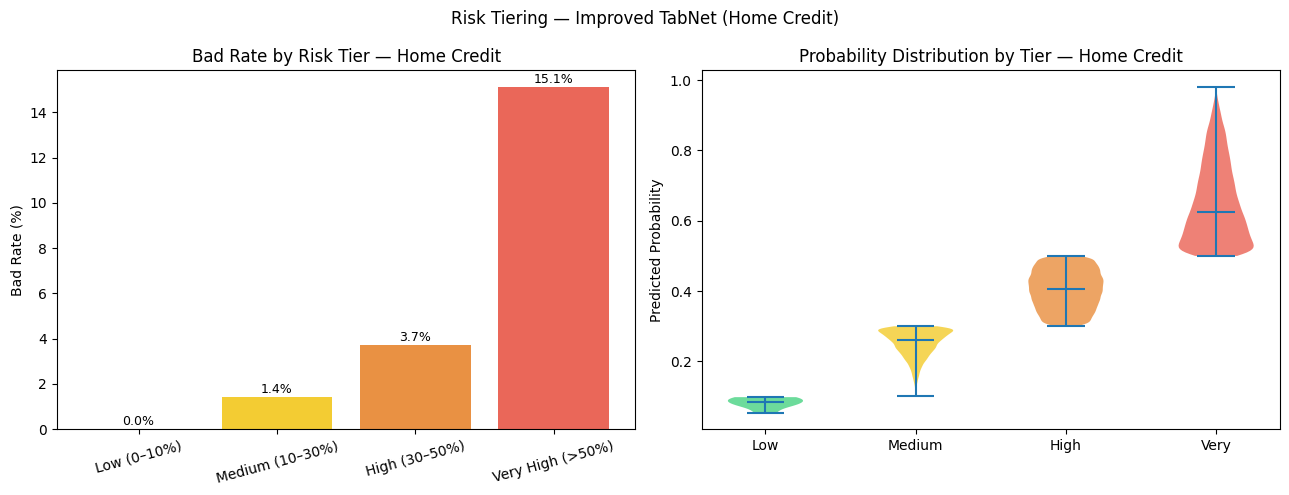

In [51]:
# GMSC
stats_gm = run_risk_tiering(
    mha_gm_wrapper, X_gm_fe_te_np, y_gm_test.values.astype(np.int64),
    tag='Give Me Some Credit',
    bins=[0, 0.3, 0.5, 0.7, 1.0],
    labels=['Low (<30%)', 'Medium (30–50%)', 'High (50–70%)', 'Very High (>70%)']
)

# HC
stats_hc = run_risk_tiering(
    mha_hc_wrapper, X_fe_te_np, y_test.values.astype(np.int64),
    tag='Home Credit',
    bins=[0, 0.2, 0.4, 0.6, 1.0],
    labels=['Low (<20%)', 'Medium (20–40%)', 'High (40–60%)', 'Very High (>60%)']
)

C. Thống kê & Báo cáo
GMSC TabNet AUC : 0.8693
HC   TabNet AUC : 0.7614

── C1. Summary — Give Me Some Credit ──
                        Model  Train AUC  Test AUC  Test Gini  Test KS  F1 (Bad)
Improved TabNet MHA (with FE)     0.8692    0.8693     0.7385   0.5821    0.3386
     TabNet default (with FE)     0.8699    0.8680     0.7361   0.5802    0.3491
       TabNet default (no FE)     0.8648    0.8662     0.7324   0.5778    0.3402
                     LightGBM     0.9014    0.8660     0.7321   0.5786    0.3277
                Random Forest     0.8770    0.8658     0.7316   0.5824    0.3341
          Logistic Regression     0.8600    0.8654     0.7308   0.5734    0.3309
                     CatBoost     0.9344    0.8570     0.7141   0.5612    0.3243
                Decision Tree     0.8632    0.8548     0.7096   0.5709    0.3241
                      XGBoost     0.9442    0.8500     0.7000   0.5520    0.3143

── C1. Summary — Home Credit ──
                        Model  Train AUC  Te

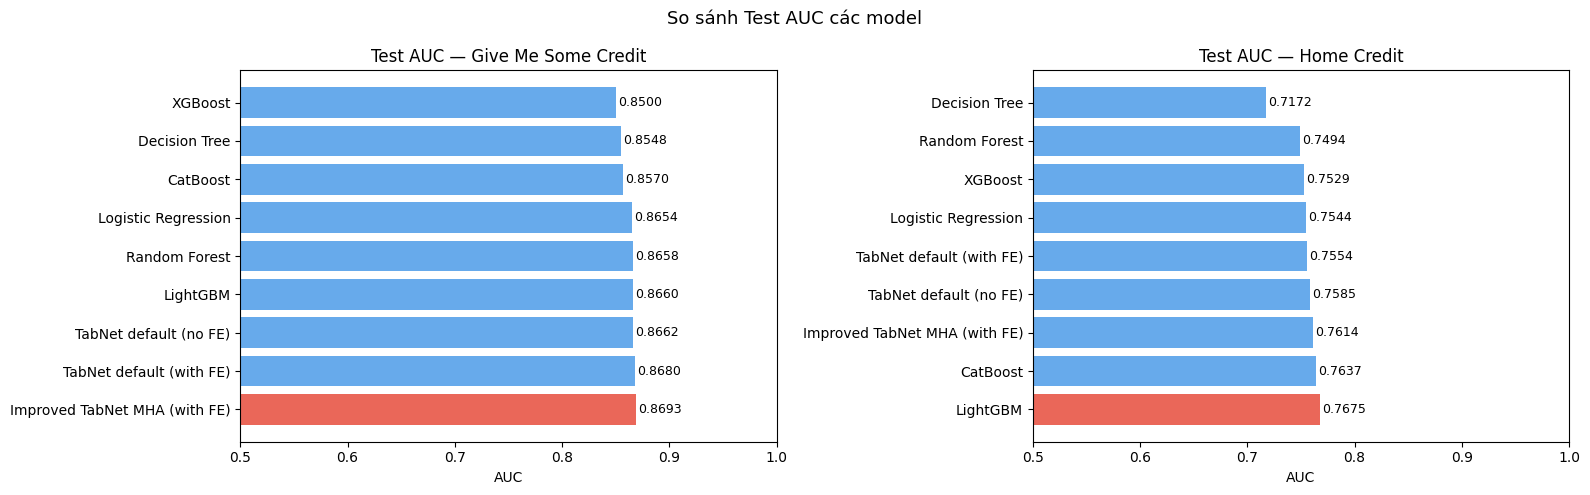


── C3. ROC Curve ──


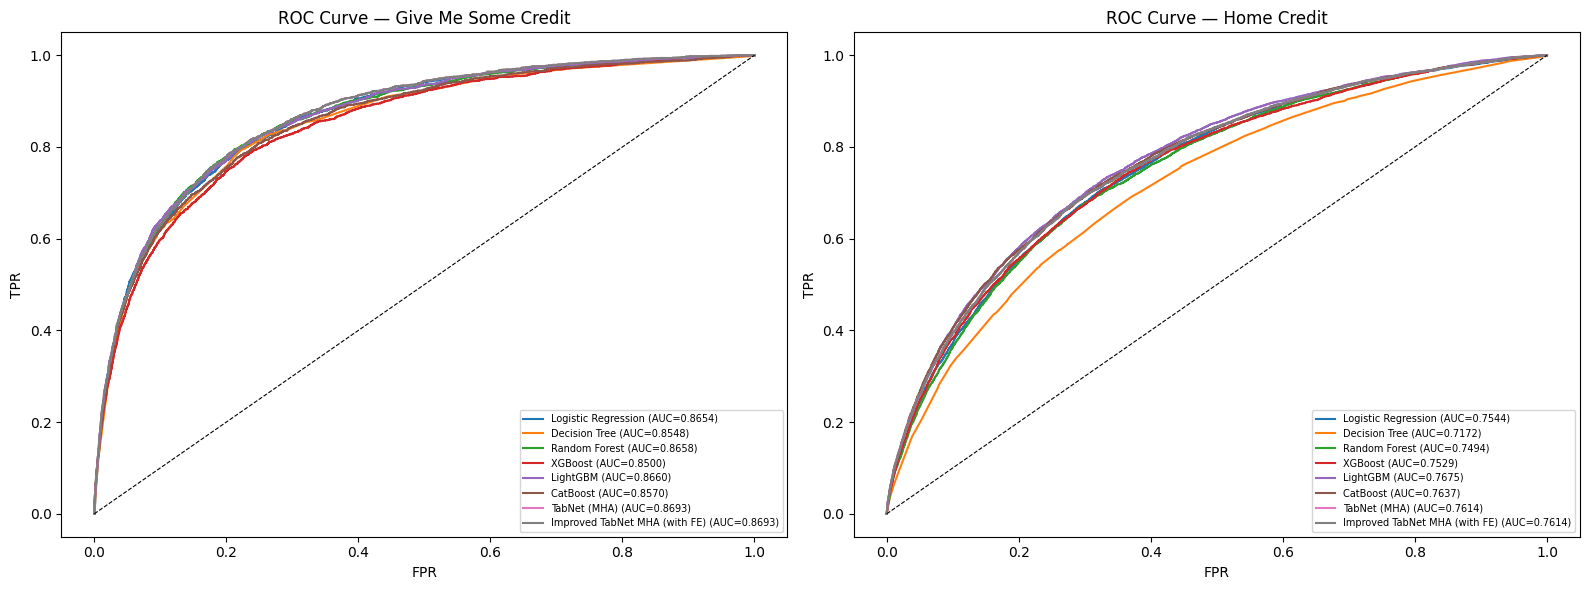


── C4. Learning Curve ──


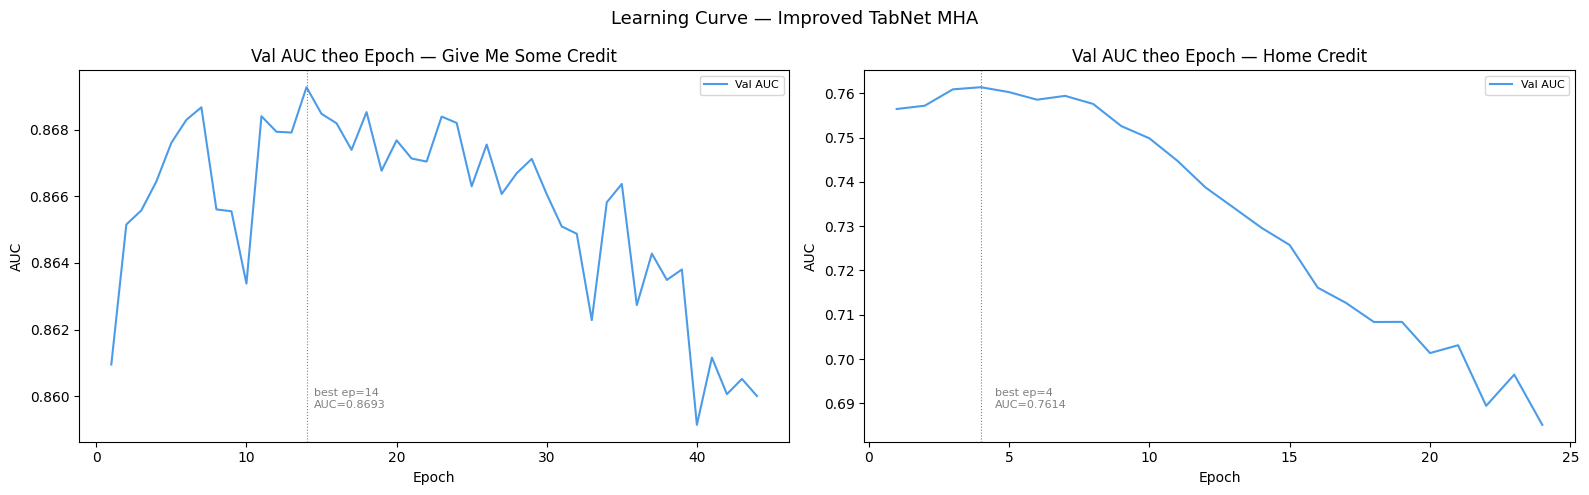


── C5. Confusion Matrix ──

── Classification Report — Give Me Some Credit (Improved TabNet MHA (with FE)) ──
              precision    recall  f1-score   support

        Good       0.98      0.72      0.83     27995
         Bad       0.18      0.85      0.29      2005

    accuracy                           0.72     30000
   macro avg       0.58      0.78      0.56     30000
weighted avg       0.93      0.72      0.79     30000


── Classification Report — Home Credit (LightGBM) ──
              precision    recall  f1-score   support

        Good       0.96      0.71      0.82     56538
         Bad       0.17      0.69      0.28      4965

    accuracy                           0.71     61503
   macro avg       0.57      0.70      0.55     61503
weighted avg       0.90      0.71      0.77     61503



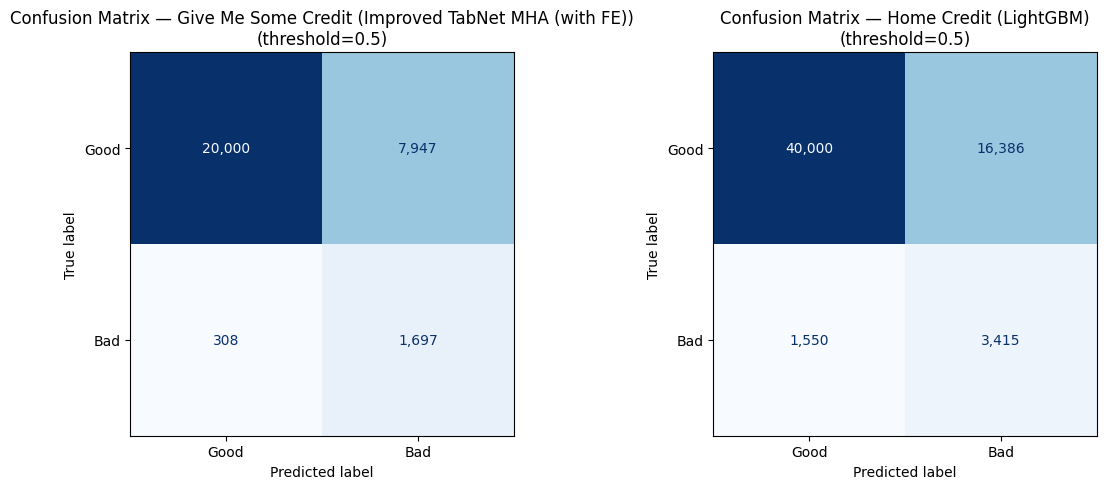

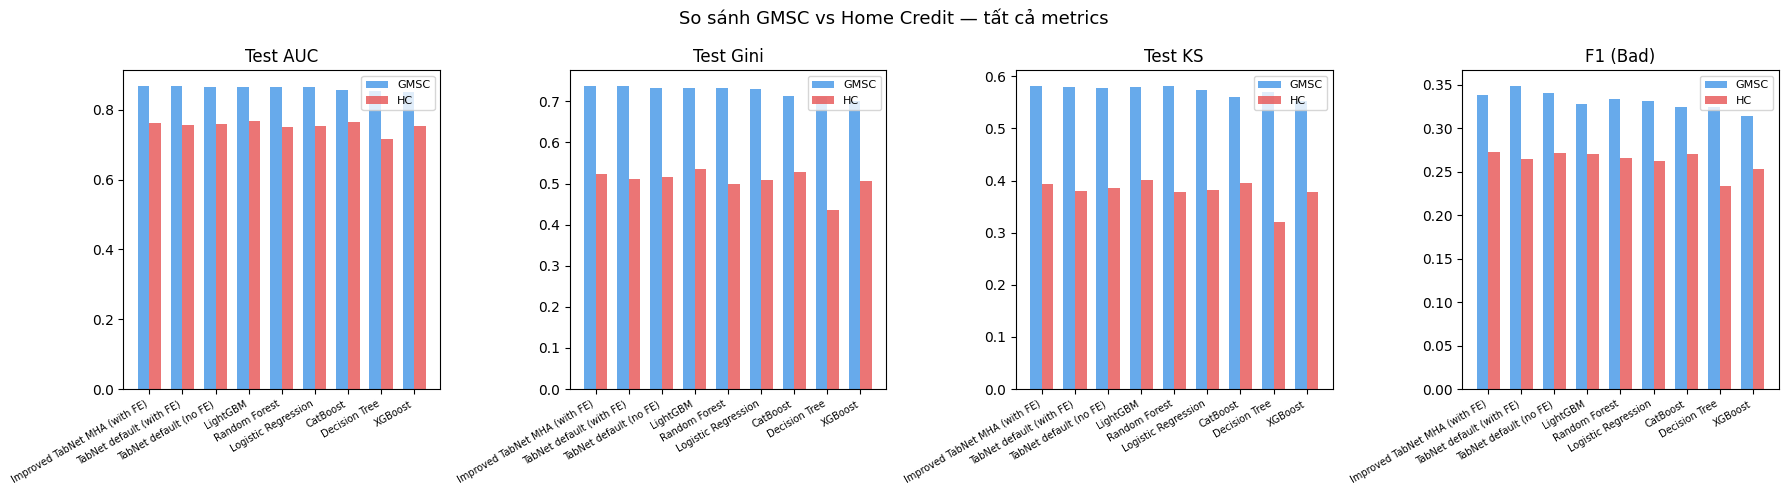


Đã export: C7_summary_all.csv
            Dataset                         Model  Test AUC  Test Gini  Test KS  F1 (Bad)
Give Me Some Credit Improved TabNet MHA (with FE)    0.8693     0.7385   0.5821    0.3386
Give Me Some Credit      TabNet default (with FE)    0.8680     0.7361   0.5802    0.3491
Give Me Some Credit        TabNet default (no FE)    0.8662     0.7324   0.5778    0.3402
Give Me Some Credit                      LightGBM    0.8660     0.7321   0.5786    0.3277
Give Me Some Credit                 Random Forest    0.8658     0.7316   0.5824    0.3341
Give Me Some Credit           Logistic Regression    0.8654     0.7308   0.5734    0.3309
Give Me Some Credit                      CatBoost    0.8570     0.7141   0.5612    0.3243
Give Me Some Credit                 Decision Tree    0.8548     0.7096   0.5709    0.3241
Give Me Some Credit                       XGBoost    0.8500     0.7000   0.5520    0.3143
        Home Credit                      LightGBM    0.7675     0.535

In [83]:
print('='*60)
print('C. Thống kê & Báo cáo')
print('='*60)

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (roc_curve, confusion_matrix,
                              ConfusionMatrixDisplay, classification_report,
                              roc_auc_score)

# ── C0. Thêm TabNet vào results dict ─────────────────────────
results_gm['Improved TabNet MHA (with FE)'] = {
    'y_true': np.array(y_gm_test),
    'y_prob': mha_gm_wrapper.predict_proba(X_gm_fe_te_np)[:, 1],
    'auc':    mha_gm_test['auc'],
}

results_hc['Improved TabNet MHA (with FE)'] = {
    'y_true': np.array(y_test),
    'y_prob': mha_hc_wrapper.predict_proba(X_test_tn)[:, 1],
    'auc':    mha_hc_test['auc'],
}

print(f"GMSC TabNet AUC : {results_gm['Improved TabNet MHA (with FE)']['auc']:.4f}")
print(f"HC   TabNet AUC : {results_hc['Improved TabNet MHA (with FE)']['auc']:.4f}")

# ── C1. Summary Table từng dataset ───────────────────────────
print('\n── C1. Summary — Give Me Some Credit ──')
print(df_summary_gm[['Model','Train AUC','Test AUC','Test Gini',
                       'Test KS','F1 (Bad)']].to_string(index=False))

print('\n── C1. Summary — Home Credit ──')
print(df_summary_hc[['Model','Train AUC','Test AUC','Test Gini',
                       'Test KS','F1 (Bad)']].to_string(index=False))

# ── C2. Bar chart so sánh Test AUC ───────────────────────────
print('\n── C2. Bar chart so sánh Test AUC──')

# dùng .copy() để tránh ô nhiễm từ C7 thêm cột Dataset
df_gm_plot = df_summary_gm[['Model','Test AUC']].copy().dropna()
df_hc_plot = df_summary_hc[['Model','Test AUC']].copy().dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, df_plot, title in zip(axes,
    [df_gm_plot, df_hc_plot],
    ['Give Me Some Credit', 'Home Credit']):
    colors = ['#E74C3C' if v == df_plot['Test AUC'].max() else '#4C9BE8'
              for v in df_plot['Test AUC']]
    bars = ax.barh(df_plot['Model'], df_plot['Test AUC'], color=colors, alpha=0.85)
    ax.set_xlim(0.5, 1.0)
    ax.set_title(f'Test AUC — {title}')
    ax.set_xlabel('AUC')
    for bar, v in zip(bars, df_plot['Test AUC']):
        ax.text(v + 0.002, bar.get_y() + bar.get_height()/2,
                f'{v:.4f}', va='center', fontsize=9)
plt.suptitle('So sánh Test AUC các model', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/C2_auc_comparison.png', dpi=150)
plt.show()

# ── C3. ROC Curve ─────────────────────────────────────────────
print('\n── C3. ROC Curve ──')
def plot_roc_all(results, title, ax):
    for name, res in results.items():
        fpr, tpr, _ = roc_curve(res['y_true'], res['y_prob'])
        ax.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.4f})", lw=1.5)
    ax.plot([0,1],[0,1], 'k--', lw=0.8)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f'ROC Curve — {title}')
    ax.legend(fontsize=7, loc='lower right')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_roc_all(results_gm, 'Give Me Some Credit', axes[0])
plot_roc_all(results_hc, 'Home Credit',          axes[1])
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/C3_roc_curves.png', dpi=150)
plt.show()

# ── C4. Learning Curve (AUC theo epoch) ──────────────────────
print('\n── C4. Learning Curve ──')

def plot_learning_curve(hist, title, ax):
    epochs = range(1, len(hist) + 1)
    ax.plot(epochs, hist, lw=1.5, color='#4C9BE8', label='Val AUC')
    best_ep  = int(np.argmax(hist)) + 1
    best_auc = max(hist)
    ax.axvline(best_ep, color='gray', lw=0.8, linestyle=':')
    ax.text(best_ep + 0.5, min(hist) + (best_auc - min(hist)) * 0.05,
            f'best ep={best_ep}\nAUC={best_auc:.4f}', fontsize=8, color='gray')
    ax.set_title(f'Val AUC theo Epoch — {title}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('AUC')
    ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_learning_curve(mha_gm_hist, 'Give Me Some Credit', axes[0])
plot_learning_curve(mha_hc_hist, 'Home Credit',          axes[1])

plt.suptitle('Learning Curve — Improved TabNet MHA', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/C4_learning_curve.png', dpi=150)
plt.show()

# ── C5. Confusion Matrix (best model mỗi dataset) ────────────
print('\n── C5. Confusion Matrix ──')
def plot_cm(y_true, y_prob, title, ax, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Good','Bad'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    for text in ax.texts:
        try:
            val = float(text.get_text())
            text.set_text(f'{int(round(val)):,}')
        except:
            pass
    ax.set_title(f'Confusion Matrix — {title}\n(threshold={threshold})')
    print(f'\n── Classification Report — {title} ──')
    print(classification_report(y_true, y_pred, target_names=['Good','Bad']))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_cm(results_gm[best_gm]['y_true'], results_gm[best_gm]['y_prob'],
        f'Give Me Some Credit ({best_gm})', axes[0])
plot_cm(results_hc[best_hc]['y_true'], results_hc[best_hc]['y_prob'],
        f'Home Credit ({best_hc})',          axes[1])
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/C5_confusion_matrix.png', dpi=150)
plt.show()

# ── C6. So sánh 2 dataset cạnh nhau ──────────────────────────
metrics = ['Test AUC', 'Test Gini', 'Test KS', 'F1 (Bad)']
fig, axes = plt.subplots(1, len(metrics), figsize=(18, 5))
for ax, metric in zip(axes, metrics):
    gm_vals = df_summary_gm.set_index('Model')[metric]
    hc_vals = df_summary_hc.set_index('Model')[metric]
    common  = gm_vals.index.intersection(hc_vals.index)
    x = np.arange(len(common)); w = 0.35
    ax.bar(x - w/2, gm_vals[common], w, label='GMSC', color='#4C9BE8', alpha=0.85)
    ax.bar(x + w/2, hc_vals[common], w, label='HC',   color='#E85D5D', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(common, rotation=30, ha='right', fontsize=7)
    ax.set_title(metric)
    ax.legend(fontsize=8)
plt.suptitle('So sánh GMSC vs Home Credit — tất cả metrics', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/C6_dataset_comparison.png', dpi=150)
plt.show()

# ── C7. Export tổng hợp ───────────────────────────────────────
# dùng .copy() để không làm hỏng df_summary_gm/hc gốc
df_gm_export = df_summary_gm.copy()
df_hc_export = df_summary_hc.copy()
df_gm_export['Dataset'] = 'Give Me Some Credit'
df_hc_export['Dataset'] = 'Home Credit'
df_all = pd.concat([df_gm_export, df_hc_export], ignore_index=True)
df_all.to_csv(f'{OUTPUT_DIR}/C7_summary_all.csv', index=False)
print('\nĐã export: C7_summary_all.csv')
print(df_all[['Dataset','Model','Test AUC','Test Gini','Test KS','F1 (Bad)']].to_string(index=False))

In [81]:
print(type(mha_gm_hist))
print(mha_gm_hist[0])   # xem phần tử đầu tiên có gì

<class 'list'>
0.8609531360026439


# PHẦN D - LƯU MODEL ĐỂ DEMO

Dùng model đã train của Give me some credit

In [67]:
import pickle, json, os
import numpy as np
import pandas as pd
import torch

print('='*60)
print('D. Lưu model để demo — Give Me Some Credit')
print('='*60)

DEMO_DIR = f'{OUTPUT_DIR}/demo_gmsc'
os.makedirs(DEMO_DIR, exist_ok=True)

# ── D1. Lưu PyTorch model weights ────────────────────────────
# Convert numpy scalars → native Python types để tránh UnpicklingError
# khi load lại với weights_only=True (default từ PyTorch 2.6)
torch.save({
    'model_state_dict': mha_gm_raw.state_dict(),
    'model_config': {
        'n_features': int(X_gm_fe_tr_np.shape[1]),
        'n_d':        int(bp_gm['n_d']),
        'n_steps':    int(bp_gm['n_steps']),
        'n_heads':    int(bp_gm['n_heads']),
        'd_model':    int(bp_gm['d_model']),
        'dropout':    float(bp_gm['dropout']),
        'gamma':      float(bp_gm['gamma']),
    },
    'best_auc': float(mha_gm_test['auc']),
}, f'{DEMO_DIR}/tabnet_gmsc.pt')
print('Saved: tabnet_gmsc.pt')

# ── D2. Lưu preprocessors ────────────────────────────────────
with open(f'{DEMO_DIR}/qt_gm.pkl', 'wb') as f:
    pickle.dump(qt_gm, f)
print('Saved: qt_gm.pkl')

# ── D3. Lưu best params ──────────────────────────────────────
with open(f'{DEMO_DIR}/bp_gm.json', 'w') as f:
    json.dump(bp_gm, f, indent=2)
print('Saved: bp_gm.json')

# ── D4. Lưu feature columns ──────────────────────────────────
feature_cols = list(X_gm_train_tn.columns)
with open(f'{DEMO_DIR}/feature_cols.json', 'w') as f:
    json.dump(feature_cols, f, indent=2)
print(f'Saved: feature_cols.json ({len(feature_cols)} features)')

# ── D5. Lưu summary kết quả ──────────────────────────────────
df_summary_gm.to_csv(f'{DEMO_DIR}/summary_gmsc.csv', index=False)
stats_gm.to_csv(f'{DEMO_DIR}/risk_tiering_gmsc.csv', index=False)
print('Saved: summary_gmsc.csv, risk_tiering_gmsc.csv')

# ── D6. Hàm load lại để demo ─────────────────────────────────
def load_demo_model(demo_dir=DEMO_DIR):
    """Load model + preprocessor để dùng trong demo."""
    # Load config & weights
    # weights_only=True an toàn vì model_config chỉ chứa Python thuần (int/float)
    ckpt = torch.load(
        f'{demo_dir}/tabnet_gmsc.pt',
        map_location='cpu',
        weights_only=True,
    )
    cfg   = ckpt['model_config']
    model = ImprovedTabNetClassifier(
        n_features = cfg['n_features'],
        n_d        = cfg['n_d'],
        n_steps    = cfg['n_steps'],
        n_heads    = cfg['n_heads'],
        d_model    = cfg['d_model'],
        dropout    = cfg['dropout'],
        gamma      = cfg['gamma'],
    )
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()

    # Load preprocessor
    with open(f'{demo_dir}/qt_gm.pkl', 'rb') as f:
        qt = pickle.load(f)

    # Load feature cols
    with open(f'{demo_dir}/feature_cols.json') as f:
        feature_cols = json.load(f)

    device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    wrapper = ModelWrapper(model.to(device), device)
    print(f'Loaded model | AUC={ckpt["best_auc"]:.4f} | features={len(feature_cols)}')
    return wrapper, qt, feature_cols

# ── D7. Test load lại ────────────────────────────────────────
wrapper_loaded, qt_loaded, cols_loaded = load_demo_model()

# Predict thử 5 samples
sample     = X_gm_fe_te_np[:5]
prob_check = wrapper_loaded.predict_proba(sample)[:, 1]
print(f'\nSanity check — predicted probs: {prob_check.round(4)}')

# ── D8. Hàm predict cho 1 khách hàng (dùng trong demo UI) ───
def predict_single(raw_input: dict, qt, feature_cols, wrapper):
    """
    raw_input: dict các feature đã FE, ví dụ:
        {'RevolvingUtilizationOfUnsecuredLines': 0.5, 'age': 45, ...}
    """
    df_input  = pd.DataFrame([raw_input])[feature_cols]
    num_cols  = df_input.select_dtypes(include='number').columns.tolist()
    df_input[num_cols] = qt.transform(df_input[num_cols])
    df_input[num_cols] = df_input[num_cols].clip(-5, 5)
    X_np = df_input.values.astype(np.float32)
    prob = wrapper.predict_proba(X_np)[0, 1]
    tier = ('Low'       if prob < 0.3 else
            'Medium'    if prob < 0.5 else
            'High'      if prob < 0.7 else 'Very High')
    return {'probability': round(float(prob), 4), 'risk_tier': tier}

print('\nDemo predict_single:')
sample_dict = dict(zip(cols_loaded, X_gm_fe_te_np[0]))
print(predict_single(sample_dict, qt_loaded, cols_loaded, wrapper_loaded))

print(f'\nTất cả file demo đã lưu tại: {DEMO_DIR}')
print(os.listdir(DEMO_DIR))

D. Lưu model để demo — Give Me Some Credit
Saved: tabnet_gmsc.pt
Saved: qt_gm.pkl
Saved: bp_gm.json
Saved: feature_cols.json (23 features)
Saved: summary_gmsc.csv, risk_tiering_gmsc.csv
Loaded model | AUC=0.8693 | features=23

Sanity check — predicted probs: [0.2829 0.3336 0.2352 0.3058 0.318 ]

Demo predict_single:
{'probability': 0.4518, 'risk_tier': 'Medium'}

Tất cả file demo đã lưu tại: outputs/demo_gmsc
['feature_cols.json', 'summary_gmsc.csv', 'risk_tiering_gmsc.csv', 'bp_gm.json', 'tabnet_gmsc.pt', 'qt_gm.pkl']
